In [ ]:

# --- 1. Initial installations and imports ---

# Importing essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# Import XGBoost
from xgboost import XGBRegressor
# Import MLPRegressor
from sklearn.neural_network import MLPRegressor

print("Libraries loaded")

Libraries loaded


In [ ]:
# --- 1. Mount Google Drive ---
from google.colab import drive
drive.mount('/content/gdrive')

# --- 2. Path to the Excel file ---
caminho_arquivo = 'Insert the path to df_final_electricity_consumption_.xlsx here'

# --- 3. Load the .xlsx file ---
tabela_dados = pd.read_excel(caminho_arquivo, sheet_name=0)

# Check the first rows
print("Primeiras 10 linhas do dataset:")
print(tabela_dados.head(10))

# Check columns
print(f"\nAvailable columns:")
print(tabela_dados.columns.tolist())

print(f"\nDataset shape: {tabela_dados.shape}")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Primeiras 10 linhas do dataset:
        Date  Month  Day  Year       City  Electricity_consumption  \
0 2021-01-01      1    1  2021  Campo_bom                248544.67   
1 2021-01-02      1    2  2021  Campo_bom                310680.84   
2 2021-01-03      1    3  2021  Campo_bom                323108.07   
3 2021-01-04      1    4  2021  Campo_bom                236117.44   
4 2021-01-05      1    5  2021  Campo_bom                223690.20   
5 2021-01-06      1    6  2021  Campo_bom                228661.10   
6 2021-01-07      1    7  2021  Campo_bom                228661.10   
7 2021-01-08      1    8  2021  Campo_bom                214652.22   
8 2021-01-09      1    9  2021  Campo_bom                268315.27   
9 2021-01-10      1   10  2021  Campo_bom                279047.88   

   Total_daily_precipitation  Average_dewpoint_temp  Max_temperatu

# **Preprocessing**

In [ ]:
# Rename columns for easier use
colunas_corrigidas = {
    'Date': 'Date',
    'Month': 'Month',
    'Day': 'Day',
    'Year': 'Year',
    'City': 'City',
    'Electricity_consumption': 'Electricity_consumption',
    'Total_daily_precipitation': 'Total_daily_precipitation',
    'Average_dewpoint_temp': 'Average_dewpoint_temp',
    'Max_temperature': 'Max_temperature',
    'Min_temperature': 'Min_temperature',
    'Average_humidity': 'Average_humidity',
    'Max_wind_gust': 'Max_wind_gust',
    'Average_wind_speed': 'Average_wind_speed',
    'Flood_risk_levels': 'Flood_risk_levels',
    'Flood_event': 'Flood_event'
}

# Apply renaming
tabela_dados = tabela_dados.rename(columns=colunas_corrigidas)

# Check if everything is correct
print("\nColumns after renaming:")
print(tabela_dados.columns.tolist())


Columns after renaming:
['Date', 'Month', 'Day', 'Year', 'City', 'Electricity_consumption', 'Total_daily_precipitation', 'Average_dewpoint_temp', 'Max_temperature', 'Min_temperature', 'Average_humidity', 'Max_wind_gust', 'Average_wind_speed', 'Flood_risk_levels', 'Flood_event']


In [ ]:
#1. Convert Date to Datetime
tabela_dados['Date'] = pd.to_datetime(tabela_dados['Date'])

#2. Ensure that Flood_event is numeric (0/1)
tabela_dados['Flood_event'] = tabela_dados['Flood_event'].astype(int)

# 3. Mapping ORDINAL to Flood_risk_levels (increasing severity)
flood_risk_map = {
    'No_rain': 0,
    'Light_Rain': 1,
    'Heavy_Rain': 2,
    'Very_Heavy_Rain': 3,
    'Extreme_Rainfall': 4
}
tabela_dados['Flood_risk_ordinal'] = tabela_dados['Flood_risk_levels'].map(flood_risk_map)

#4. Check ordinal mapping
print("\nMapping Flood_risk_levels to ordinal:")
print(tabela_dados[['Flood_risk_levels', 'Flood_risk_ordinal']].drop_duplicates().sort_values('Flood_risk_ordinal'))

#5. Create a binary variable for "High Risk" (Very Heavy Rain or Extreme Rainfall)
tabela_dados['High_risk_flood'] = (tabela_dados['Flood_risk_ordinal'] >= 3).astype(int)

#6. Create an extreme precipitation variable (≥ 50 mm) — direct physical criterion
tabela_dados['Heavy_precip'] = (tabela_dados['Total_daily_precipitation'] >= 50).astype(int)

#7. Create a "Peak Consumption" variable (top 10% of consumption)
p90 = tabela_dados['Electricity_consumption'].quantile(0.90)
tabela_dados['Consumo_pico'] = (tabela_dados['Electricity_consumption'] > p90).astype(int)
print(f"\n90th percentile threshold (peak consumption): {p90:.2f} kWh")
print(f"Proportion of days with peak consumption: {tabela_dados['Consumo_pico'].mean():.2%}")

#8. Remove only Flood_risk_levels (City will be kept, but hardcoded later)
cols_to_drop = ['Flood_risk_levels']
tabela_dados = tabela_dados.drop(columns=cols_to_drop, errors='ignore')

#9. Apply LabelEncoder to the City column.
from sklearn.preprocessing import LabelEncoder

le_city = LabelEncoder()
tabela_dados['City_encoded'] = le_city.fit_transform(tabela_dados['City'])

# Show mapping
print("\nCity Mapping:")
for i, city in enumerate(le_city.classes_):
    print(f"  {city} → {i}")

#10. Check for null values ​​(final confirmation)
print("\nNull values ​​per column (final confirmation):")
nulos = tabela_dados.isnull().sum()
if (nulos == 0).all():
    print("No null values ​​found.")
else:
    print(nulos[nulos > 0])

#11. General information about the post-processing dataset
print("\nDataset information after preprocessing:")
print(tabela_dados.info())

#12. Display first lines for verification
print("\nFirst 5 lines (verification):")
print(tabela_dados[['Date', 'City', 'City_encoded', 'Flood_risk_ordinal', 'High_risk_flood', 'Electricity_consumption']].head())


Mapping Flood_risk_levels to ordinal:
    Flood_risk_levels  Flood_risk_ordinal
0             No_rain                   0
4          Light_Rain                   1
5          Heavy_Rain                   2
23    Very_Heavy_Rain                   3
896  Extreme_Rainfall                   4

90th percentile threshold (peak consumption): 237259.86 kWh
Proportion of days with peak consumption: 10.00%

City Mapping:
  Campo_bom → 0
  Canela → 1
  Erechim → 2
  Vacaria → 3

Null values ​​per column (final confirmation):
No null values ​​found.

Dataset information after preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       4380 non-null   datetime64[ns]
 1   Month                      4380 non-null   int64         
 2   Day                        4380 non-null   int64 

## Create lag features

Add columns to the DataFrame containing the energy consumption of previous days (lags).


In [ ]:
#1. Create a copy of the DataFrame
tabela_dados_lags = tabela_dados.copy()

#2. Define a list of lags
lags = [1, 2, 7]

#3. Add lag columns
for lag in lags:
    tabela_dados_lags[f'consumption_lag_{lag}'] = tabela_dados_lags['Electricity_consumption'].shift(lag)

# Verify the first rows of the DataFrame with the new columns
print("First rows of the DataFrame with lag columns:")
display(tabela_dados_lags.head(10))

# Check the last lines to see NaN values ​​entered by shift.
print("\nLast rows of the DataFrame with lag columns:")
display(tabela_dados_lags.tail(10))

First rows of the DataFrame with lag columns:


,Date,Month,Day,Year,City,Electricity_consumption,Total_daily_precipitation,Average_dewpoint_temp,Max_temperature,Min_temperature,...,Average_wind_speed,Flood_event,Flood_risk_ordinal,High_risk_flood,Heavy_precip,Consumo_pico,City_encoded,consumption_lag_1,consumption_lag_2,consumption_lag_7
0,2021-01-01,1,1,2021,Campo_bom,248544.67,0.0,16.79,30.3,17.2,...,1.50,0,0,0,0,1,0,NaN,NaN,NaN
1,2021-01-02,1,2,2021,Campo_bom,310680.84,0.0,18.47,32.1,13.9,...,1.13,0,0,0,0,1,0,248544.67,NaN,NaN
2,2021-01-03,1,3,2021,Campo_bom,323108.07,0.0,18.68,32.6,16.8,...,1.42,0,0,0,0,1,0,310680.84,248544.67,NaN
3,2021-01-04,1,4,2021,Campo_bom,236117.44,0.0,14.32,34.4,17.8,...,1.35,0,0,0,0,0,0,323108.07,310680.84,NaN
4,2021-01-05,1,5,2021,Campo_bom,223690.20,1.6,11.78,31.2,21.8,...,1.18,0,1,0,0,0,0,236117.44,323108.07,NaN
5,2021-01-06,1,6,2021,Campo_bom,228661.10,20.0,14.54,33.3,21.3,...,1.54,0,2,0,0,0,0,223690.20,236117.44,NaN
6,2021-01-07,1,7,2021,Campo_bom,228661.10,0.0,14.66,34.2,22.9,...,1.74,0,0,0,0,0,0,228661.10,223690.20,NaN
7,2021-01-08,1,8,2021,Campo_bom,214652.22,0.0,15.24,35.2,20.9,...,1.24,0,0,0,0,0,0,228661.10,228661.10,248544.67
8,2021-01-09,1,9,2021,Campo_bom,268315.27,0.0,16.10,36.2,16.4,...,1.08,0,0,0,0,1,0,214652.22,228661.10,310680.84
9,2021-01-10,1,10,2021,Campo_bom,279047.88,0.0,16.93,37.0,24.5,...,1.25,0,0,0,0,1,0,268315.27,214652.22,323108.07



Last rows of the DataFrame with lag columns:


,Date,Month,Day,Year,City,Electricity_consumption,Total_daily_precipitation,Average_dewpoint_temp,Max_temperature,Min_temperature,...,Average_wind_speed,Flood_event,Flood_risk_ordinal,High_risk_flood,Heavy_precip,Consumo_pico,City_encoded,consumption_lag_1,consumption_lag_2,consumption_lag_7
4370,2023-12-22,12,22,2023,Vacaria,114096.19,0.0,17.40,30.2,17.2,...,2.50,0,0,0,0,0,3,94971.50,94971.50,103229.89
4371,2023-12-23,12,23,2023,Vacaria,142620.24,16.0,16.36,27.6,15.5,...,3.14,0,2,0,0,0,3,114096.19,94971.50,129037.36
4372,2023-12-24,12,24,2023,Vacaria,148325.05,0.0,18.18,29.0,17.3,...,2.19,0,0,0,0,0,3,142620.24,114096.19,134198.86
4373,2023-12-25,12,25,2023,Vacaria,108391.38,2.2,17.53,24.6,16.0,...,4.80,0,1,0,0,0,3,148325.05,142620.24,98068.40
4374,2023-12-26,12,26,2023,Vacaria,102686.58,0.4,12.02,22.8,11.1,...,2.27,0,1,0,0,0,3,108391.38,148325.05,92906.90
4375,2023-12-27,12,27,2023,Vacaria,104968.50,0.2,8.65,25.6,9.3,...,2.62,0,1,0,0,0,3,102686.58,108391.38,94971.50
4376,2023-12-28,12,28,2023,Vacaria,104968.50,0.0,14.28,29.6,14.5,...,4.90,0,0,0,0,0,3,104968.50,102686.58,94971.50
4377,2023-12-29,12,29,2023,Vacaria,119529.35,0.4,15.87,23.8,16.8,...,3.62,0,1,0,0,0,3,104968.50,104968.50,114096.19
4378,2023-12-30,12,30,2023,Vacaria,149411.68,0.0,12.67,24.6,12.1,...,1.99,0,0,0,0,0,3,119529.35,104968.50,142620.24
4379,2023-12-31,12,31,2023,Vacaria,155388.15,0.0,12.77,25.2,10.9,...,2.33,0,0,0,0,0,3,149411.68,119529.35,148325.05


## Create moving average features

Add columns containing the moving average of energy consumption over different time windows.


In [ ]:
#1. Define a list of time windows for the moving averages.
rolling_windows = [7, 30]

#2. For each time window, calculate the moving average and add the column.
for window in rolling_windows:
    tabela_dados_lags[f'consumption_rolling_mean_{window}d'] = tabela_dados_lags['Electricity_consumption'].rolling(window=window).mean()

#3. Display the first and last rows of the resulting DataFrame
print("First rows of the DataFrame with lag and moving average columns:")
display(tabela_dados_lags.head(35)) # Displaying more rows to show the rolling mean values start appearing

print("\nLast rows of the DataFrame with lag and moving average columns:")
display(tabela_dados_lags.tail(10))

First rows of the DataFrame with lag and moving average columns:


,Date,Month,Day,Year,City,Electricity_consumption,Total_daily_precipitation,Average_dewpoint_temp,Max_temperature,Min_temperature,...,Flood_risk_ordinal,High_risk_flood,Heavy_precip,Consumo_pico,City_encoded,consumption_lag_1,consumption_lag_2,consumption_lag_7,consumption_rolling_mean_7d,consumption_rolling_mean_30d
0,2021-01-01,1,1,2021,Campo_bom,248544.67,0.0,16.79,30.3,17.2,...,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,1,2,2021,Campo_bom,310680.84,0.0,18.47,32.1,13.9,...,0,0,0,1,0,248544.67,NaN,NaN,NaN,NaN
2,2021-01-03,1,3,2021,Campo_bom,323108.07,0.0,18.68,32.6,16.8,...,0,0,0,1,0,310680.84,248544.67,NaN,NaN,NaN
3,2021-01-04,1,4,2021,Campo_bom,236117.44,0.0,14.32,34.4,17.8,...,0,0,0,0,0,323108.07,310680.84,NaN,NaN,NaN
4,2021-01-05,1,5,2021,Campo_bom,223690.20,1.6,11.78,31.2,21.8,...,1,0,0,0,0,236117.44,323108.07,NaN,NaN,NaN
5,2021-01-06,1,6,2021,Campo_bom,228661.10,20.0,14.54,33.3,21.3,...,2,0,0,0,0,223690.20,236117.44,NaN,NaN,NaN
6,2021-01-07,1,7,2021,Campo_bom,228661.10,0.0,14.66,34.2,22.9,...,0,0,0,0,0,228661.10,223690.20,NaN,257066.202857,NaN
7,2021-01-08,1,8,2021,Campo_bom,214652.22,0.0,15.24,35.2,20.9,...,0,0,0,0,0,228661.10,228661.10,248544.67,252224.424286,NaN
8,2021-01-09,1,9,2021,Campo_bom,268315.27,0.0,16.10,36.2,16.4,...,0,0,0,1,0,214652.22,228661.10,310680.84,246172.200000,NaN
9,2021-01-10,1,10,2021,Campo_bom,279047.88,0.0,16.93,37.0,24.5,...,0,0,0,1,0,268315.27,214652.22,323108.07,239877.887143,NaN



Last rows of the DataFrame with lag and moving average columns:


,Date,Month,Day,Year,City,Electricity_consumption,Total_daily_precipitation,Average_dewpoint_temp,Max_temperature,Min_temperature,...,Flood_risk_ordinal,High_risk_flood,Heavy_precip,Consumo_pico,City_encoded,consumption_lag_1,consumption_lag_2,consumption_lag_7,consumption_rolling_mean_7d,consumption_rolling_mean_30d
4370,2023-12-22,12,22,2023,Vacaria,114096.19,0.0,17.40,30.2,17.2,...,0,0,0,0,3,94971.50,94971.50,103229.89,108321.530000,113779.005333
4371,2023-12-23,12,23,2023,Vacaria,142620.24,16.0,16.36,27.6,15.5,...,2,0,0,0,3,114096.19,94971.50,129037.36,110261.941429,114926.211333
4372,2023-12-24,12,24,2023,Vacaria,148325.05,0.0,18.18,29.0,17.3,...,0,0,0,0,3,142620.24,114096.19,134198.86,112279.968571,115949.942667
4373,2023-12-25,12,25,2023,Vacaria,108391.38,2.2,17.53,24.6,16.0,...,1,0,0,0,3,148325.05,142620.24,98068.40,113754.680000,114662.442333
4374,2023-12-26,12,26,2023,Vacaria,102686.58,0.4,12.02,22.8,11.1,...,1,0,0,0,3,108391.38,148325.05,92906.90,115151.777143,112988.760000
4375,2023-12-27,12,27,2023,Vacaria,104968.50,0.2,8.65,25.6,9.3,...,1,0,0,0,3,102686.58,108391.38,94971.50,116579.920000,112763.294667
4376,2023-12-28,12,28,2023,Vacaria,104968.50,0.0,14.28,29.6,14.5,...,0,0,0,0,3,104968.50,102686.58,94971.50,118008.062857,112733.851333
4377,2023-12-29,12,29,2023,Vacaria,119529.35,0.4,15.87,23.8,16.8,...,1,0,0,0,3,104968.50,104968.50,114096.19,118784.228571,113454.866000
4378,2023-12-30,12,30,2023,Vacaria,149411.68,0.0,12.67,24.6,12.1,...,0,0,0,0,3,119529.35,104968.50,142620.24,119754.434286,115171.958333
4379,2023-12-31,12,31,2023,Vacaria,155388.15,0.0,12.77,25.2,10.9,...,0,0,0,0,3,149411.68,119529.35,148325.05,120763.448571,116729.462000


## Addressing null values ​​after feature creation

Removing null values ​​introduced by the creation of lags and moving averages.


In [ ]:
#1. Identify the columns with null values
print("Null values ​​per column before removing/filling:")
print(tabela_dados_lags.isnull().sum()[tabela_dados_lags.isnull().sum() > 0])

#2. Remove the initial lines with NaNs
initial_nan_rows_to_drop = 30
print(f"\nRemoving the first ones {initial_nan_rows_to_drop} Lines containing NaNs introduced by lags/rolling means...")
tabela_dados_cleaned = tabela_dados_lags.iloc[initial_nan_rows_to_drop:].copy()

#3. Check if there are still null values.
print("\nNull values ​​per column after removing the first rows:")
nulos_cleaned = tabela_dados_cleaned.isnull().sum()
if (nulos_cleaned == 0).all():
    print("No null values ​​found.")
else:
    print(nulos_cleaned[nulos_cleaned > 0])

print(f"\nDataFrame shapefile after cleaning: {tabela_dados_cleaned.shape}")
print("\nFirst rows of the clean DataFrame:")
display(tabela_dados_cleaned.head())

Null values ​​per column before removing/filling:
consumption_lag_1                1
consumption_lag_2                2
consumption_lag_7                7
consumption_rolling_mean_7d      6
consumption_rolling_mean_30d    29
dtype: int64

Removing the first ones 30 Lines containing NaNs introduced by lags/rolling means...

Null values ​​per column after removing the first rows:
No null values ​​found.

DataFrame shapefile after cleaning: (4350, 24)

First rows of the clean DataFrame:


,Date,Month,Day,Year,City,Electricity_consumption,Total_daily_precipitation,Average_dewpoint_temp,Max_temperature,Min_temperature,...,Flood_risk_ordinal,High_risk_flood,Heavy_precip,Consumo_pico,City_encoded,consumption_lag_1,consumption_lag_2,consumption_lag_7,consumption_rolling_mean_7d,consumption_rolling_mean_30d
30,2021-01-31,1,31,2021,Campo_bom,308421.34,30.8,19.81,29.9,20.9,...,3,1,0,1,0,296558.98,237247.19,323108.07,251336.764286,240632.665333
31,2021-02-01,2,1,2021,Campo_bom,195815.74,0.0,21.03,33.6,22.2,...,0,0,0,0,0,308421.34,296558.98,236117.44,245579.378571,236803.828667
32,2021-02-02,2,2,2021,Campo_bom,185509.65,4.6,20.62,35.5,23.0,...,1,0,0,0,0,195815.74,308421.34,223690.20,240125.014286,232217.214667
33,2021-02-03,2,3,2021,Campo_bom,189632.08,1.4,21.44,31.5,22.6,...,1,0,0,0,0,185509.65,195815.74,228661.10,234549.440000,230667.702667
34,2021-02-04,2,4,2021,Campo_bom,189632.08,25.0,19.20,27.5,20.7,...,2,0,0,0,0,189632.08,185509.65,228661.10,228973.865714,229532.432000


## Splitting training and test sets

Unsplitting the data into training and test sets is possible with the new features.


In [ ]:
print("Redefining the training and testing sets for the selected cities...")

# Redefine selected_cities and filtered_cities_data_table to ensure they are available.
cidades_selecionadas = tabela_dados_cleaned['City'].unique().tolist() # Select all unique cities
tabela_dados_filtered_cities = tabela_dados_cleaned[tabela_dados_cleaned['City'].isin(cidades_selecionadas)].copy()

# 1. Define the features (X) and the target (y) using the DataFrame tabela_dados_filtered_cities
# Exclude 'Date', 'City', 'Electricity_consumption', 'Consumo_pico', 'Pico_em_dia_risco' from the features
features_cleaned_filtered = [col for col in tabela_dados_filtered_cities.columns if col not in ['Date', 'City', 'Electricity_consumption', 'Consumo_pico', 'Pico_em_dia_risco']]
X_filtered = tabela_dados_filtered_cities[features_cleaned_filtered]
y_filtered = tabela_dados_filtered_cities['Electricity_consumption']

# 2. Separate the data into training and test sets based on year and month
# Training: years 2021, 2022, and up to November 30, 2023
X_train_cleaned = X_filtered[((tabela_dados_filtered_cities['Year'] < 2023) |
                            ((tabela_dados_filtered_cities['Year'] == 2023) & (tabela_dados_filtered_cities['Month'] < 12)))]
y_train_cleaned = y_filtered[((tabela_dados_filtered_cities['Year'] < 2023) |
                            ((tabela_dados_filtered_cities['Year'] == 2023) & (tabela_dados_filtered_cities['Month'] < 12)))]

# 3. Test: all of December 2023
X_test_cleaned = X_filtered[(tabela_dados_filtered_cities['Year'] == 2023) & (tabela_dados_filtered_cities['Month'] == 12)]
y_test_cleaned = y_filtered[(tabela_dados_filtered_cities['Year'] == 2023) & (tabela_dados_filtered_cities['Month'] == 12)]

#4. Display the shape of the resulting sets
print(f"\nShape of the training set (X_train Cleaned, x_train cleaned): {X_train_cleaned.shape}, {y_train_cleaned.shape}")
print(f"Shape of the test set (X_test Cleaned, y_test cleaned): {X_test_cleaned.shape}, {y_test_cleaned.shape}")

Redefining the training and testing sets for the selected cities...

Shape of the training set (X_train Cleaned, x_train cleaned): (4226, 20), (4226,)
Shape of the test set (X_test Cleaned, y_test cleaned): (124, 20), (124,)


## Training and evaluating models with time series features

In [ ]:
#1. Initialize dictionary for results
resultados_time_features = {}

#2. Iterate over the models
modelos_gerais = {
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'Rede Neural': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}


print("Evaluating models with time series features:")

for nome, modelo in modelos_gerais.items():
    print(f"Training and evaluating: {nome}")

    # 3a. Train the model with clean data and time features.
    modelo.fit(X_train_cleaned, y_train_cleaned)

    # 3b. Make predictions on a clean test set with time features
    y_pred_cleaned = modelo.predict(X_test_cleaned)

    # 3c. Calculate MAE
    mae_cleaned = mean_absolute_error(y_test_cleaned, y_pred_cleaned)

    # 3d. Calculate RMSE
    rmse_cleaned = np.sqrt(mean_squared_error(y_test_cleaned, y_pred_cleaned))

    # 3e. Calculate R²
    r2_cleaned = r2_score(y_test_cleaned, y_pred_cleaned)

    # 3f. Store the metrics
    resultados_time_features[nome] = {'MAE': mae_cleaned, 'RMSE': rmse_cleaned, 'R²': r2_cleaned}

#4. Convert the dictionary results into a DataFrame
df_resultados_time_features = pd.DataFrame.from_dict(resultados_time_features, orient='index')
df_resultados_time_features = df_resultados_time_features.reset_index().rename(columns={'index': 'Modelo'})

#5. Display the results DataFrame with two decimal places
print("\nResults of the evaluation on the test set with time series features:")
display(df_resultados_time_features.style.format(precision=3))

Evaluating models with time series features:
Training and evaluating: Random Forest
Training and evaluating: XGBoost
Training and evaluating: Rede Neural

Results of the evaluation on the test set with time series features:


,Modelo,MAE,RMSE,R²
0,Random Forest,7275.117,11733.307,0.972
1,XGBoost,8687.424,12293.430,0.969
2,Rede Neural,7756.419,12121.621,0.970


## View Forecasts vs. Actual Values ​​(Features with Time)


The performance of the models in predicting electricity consumption is visually confirmed by comparing the actual values ​​with the generated forecasts, as illustrated in Figure 1. This figure presents a time series for the city of Canela, highlighting the models' ability to replicate observed consumption patterns and the accuracy of their estimates. The overlay of the forecast lines onto the actual values ​​demonstrates the model's generalization, especially when equipped with time series features.

Generating Comparison Charts: Actual Values ​​vs. Current Values Model Predictions (Features with Time)
Combined plot saved: combined_prediction_plot_Canela_time_features.tiff


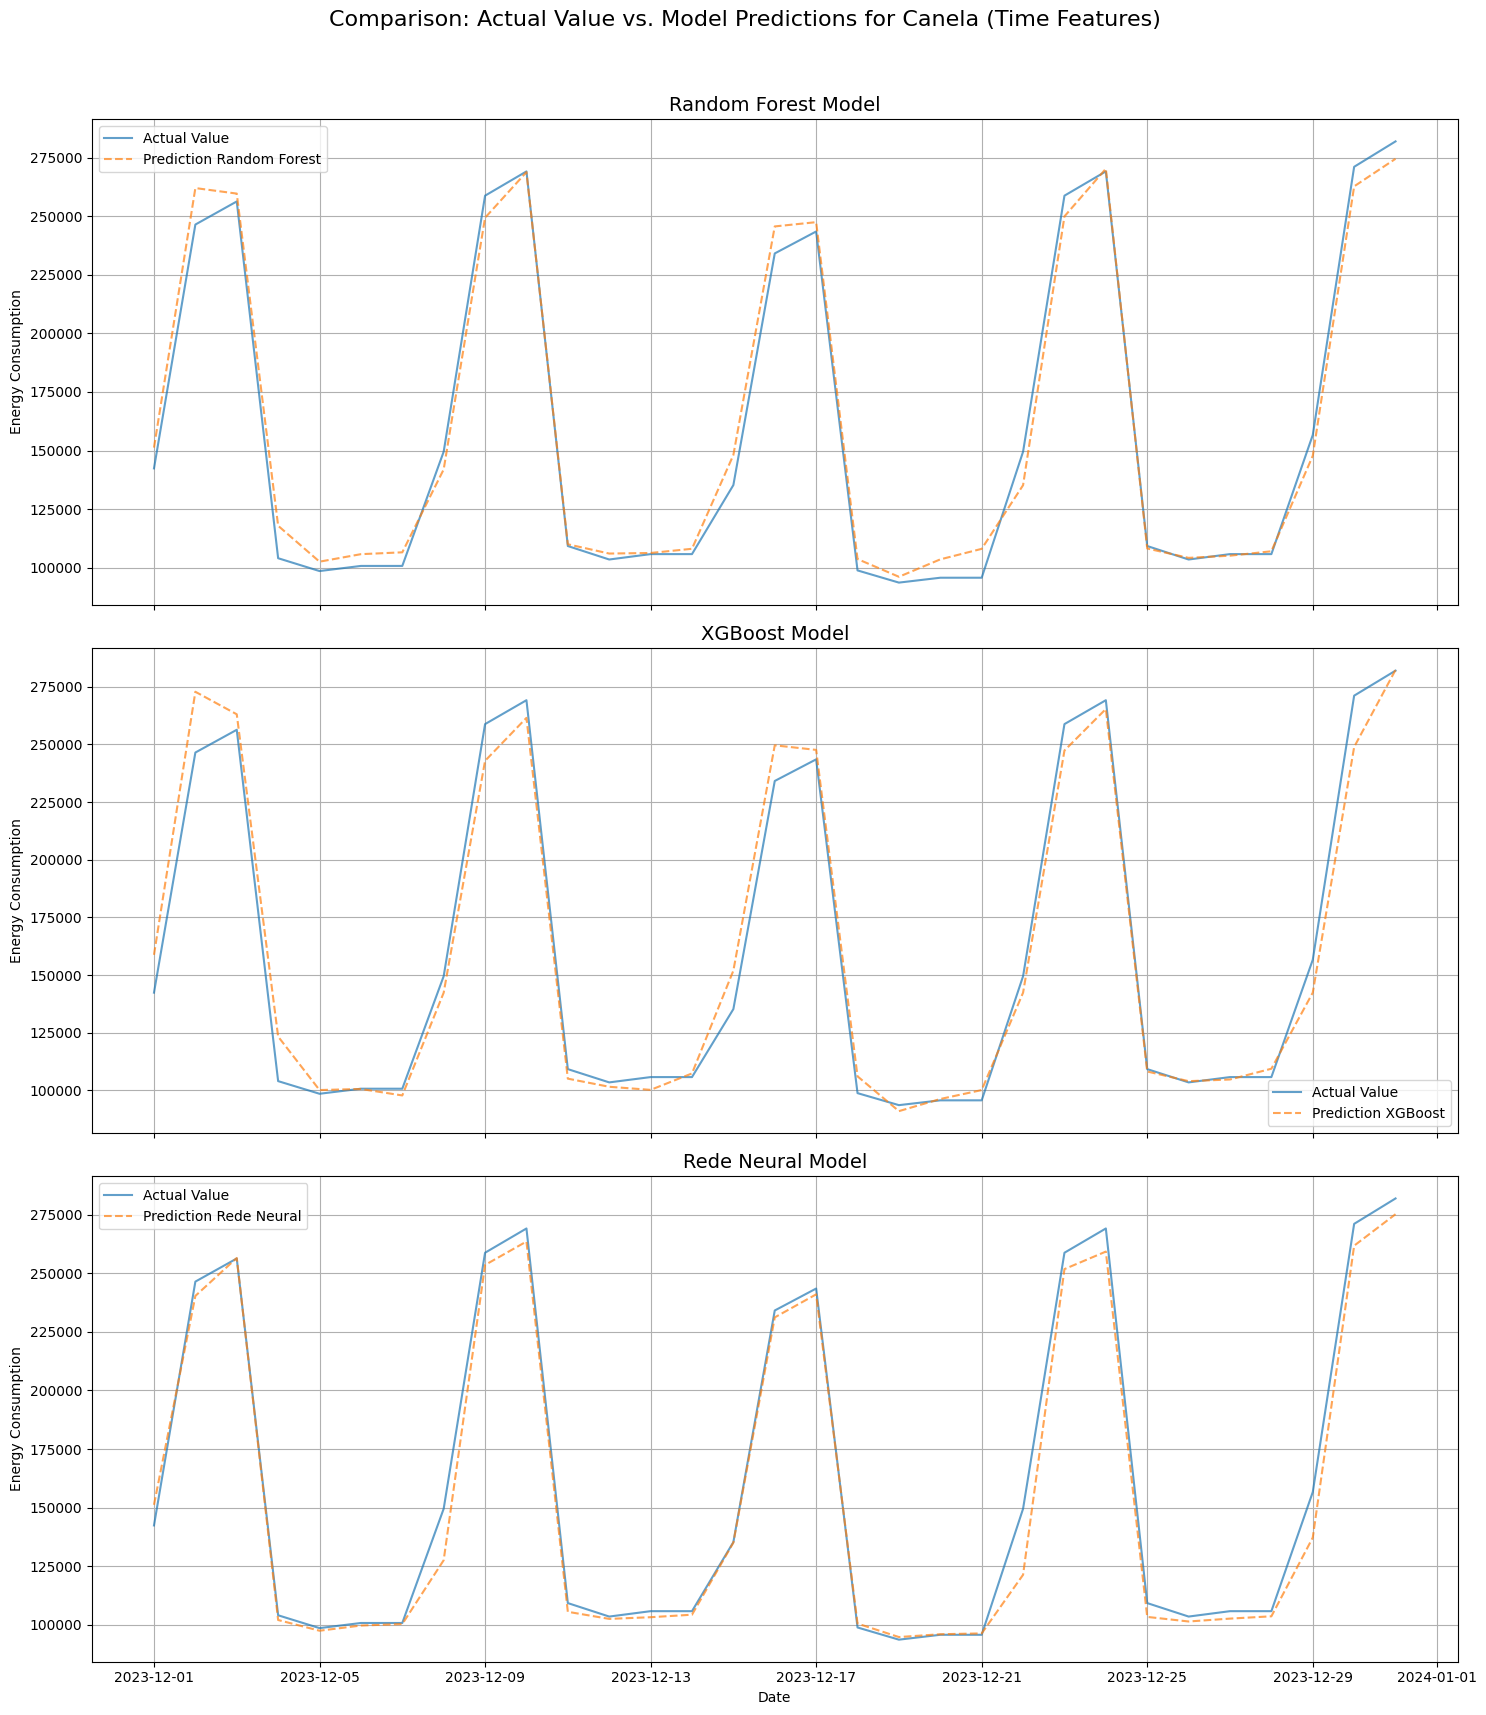

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.font_manager as fm

# Make predictions with the models on the test set (with timing features)
predictions_time_features_non_optimized = {}
for nome, modelo in modelos_gerais.items():
    # Explicitly align the columns of X_test_cleaned to match X_train_cleaned
    X_test_cleaned_aligned = X_test_cleaned[X_train_cleaned.columns]
    predictions_time_features_non_optimized[nome] = modelo.predict(X_test_cleaned_aligned)

print("Generating Comparison Charts: Actual Values ​​vs. Current Values Model Predictions (Features with Time)")

df_test_cleaned_plot = tabela_dados_cleaned.loc[X_test_cleaned.index].copy()
city_to_plot = 'Canela'
df_test_city_plot = df_test_cleaned_plot[df_test_cleaned_plot['City'] == city_to_plot].copy()
y_test_city = y_test_cleaned.loc[df_test_city_plot.index]

# Create a single figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)
fig.suptitle(f'Comparison: Actual Value vs. Model Predictions for {city_to_plot} (Time Features)', fontsize=16)

for i, (nome, y_pred) in enumerate(predictions_time_features_non_optimized.items()):
    ax = axes[i]
    y_pred_series_aligned = pd.Series(y_pred, index=X_test_cleaned_aligned.index) # Use aligned index for series
    y_pred_city = y_pred_series_aligned.loc[df_test_city_plot.index]

    ax.plot(df_test_city_plot['Date'], y_test_city, label='Actual Value', alpha=0.7)
    ax.plot(df_test_city_plot['Date'], y_pred_city, label=f'Prediction {nome}', linestyle='dashed', alpha=0.7)
    ax.set_title(f'{nome} Model', fontsize=14)
    ax.set_ylabel('Energy Consumption')
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel('Date')
plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap

# Save the combined plot as a TIFF file
filename = f'combined_prediction_plot_{city_to_plot}_time_features.tiff'
plt.savefig(filename, dpi=300, format='tiff')
print(f"Combined plot saved: {filename}")
plt.show()

## Preparing Data for Ablation


Create new training and test datasets (`X_train_ablated`, `X_test_ablated`) excluding the lag and moving average columns ('consumption_lag_1', 'consumption_lag_2', 'consumption_lag_7', 'consumption_rolling_mean_7d', 'consumption_rolling_mean_30d').


In [ ]:
print("Preparing ablated datasets...")

#1. Define the list of time series feature columns to be excluded.
columns_to_exclude_from_ablation = [
    'consumption_lag_1',
    'consumption_lag_2',
    'consumption_lag_7',
    'consumption_rolling_mean_7d',
    'consumption_rolling_mean_30d'
]

# 2. Create a new DataFrame `table data ablated` removing the columns
# Make sure we are working with a copy to avoid SettingWithCopyWarning
tabela_dados_ablated = tabela_dados_cleaned.drop(columns=columns_to_exclude_from_ablation).copy()

# 3. Define the features for the ablated set (X_ablated)
# Exclude 'Date', 'City', 'Electricity_consumption', 'Peak_consumption', 'Peak_on_risk_day' from the features
features_ablated = [col for col in tabela_dados_ablated.columns if col not in ['Date', 'City', 'Electricity_consumption', 'Consumo_pico', 'Pico_em_dia_risco']]
X_ablated = tabela_dados_ablated[features_ablated]

# 4. Set the target for the ablated set (y_ablated)
y_ablated = tabela_dados_ablated['Electricity_consumption']

# 5. Split X_ablated and y_ablated into training and test sets
# Using the same date logic employed previously
# Training: years 2021, 2022 and up to November 30, 2023
X_train_ablated = X_ablated[((tabela_dados_ablated['Year'] < 2023) |
                             ((tabela_dados_ablated['Year'] == 2023) & (tabela_dados_ablated['Month'] < 12)))]
y_train_ablated = y_ablated[((tabela_dados_ablated['Year'] < 2023) |
                             ((tabela_dados_ablated['Year'] == 2023) & (tabela_dados_ablated['Month'] < 12)))]

# Test: all of December 2023
X_test_ablated = X_ablated[(tabela_dados_ablated['Year'] == 2023) & (tabela_dados_ablated['Month'] == 12)]
y_test_ablated = y_ablated[(tabela_dados_ablated['Year'] == 2023) & (tabela_dados_ablated['Month'] == 12)]

#6. Display the shapes of the new sets
print(f"\nShape of the canned training set (X_train Ablated, x_train ablated): {X_train_ablated.shape}, {y_train_ablated.shape}")
print(f"Shape of the ablated test set (X_test_ablated, y_test_ablated): {X_test_ablated.shape}, {y_test_ablated.shape}")

Preparing ablated datasets...

Shape of the canned training set (X_train Ablated, x_train ablated): (4226, 15), (4226,)
Shape of the ablated test set (X_test_ablated, y_test_ablated): (124, 15), (124,)


## Ablation Study - Removing variables from moving averages

Train the models (Random Forest, XGBoost, Neural Network) using the new datasets without the time series features and calculate the metrics (MAE, RMSE, R²).


In [ ]:
print("Evaluating models with ablated features:")

# 1. Initialize dictionary for ablation results
resultados_ablacao = {}

# 2. Iterate over the models
# 'general_models' already contain the initialized models.
for nome, modelo in modelos_gerais.items():
    print(f"Training and evaluating: {nome} (with ablated features)")

    #2a. Train the model with the ablated data
    modelo.fit(X_train_ablated, y_train_ablated)

    #2b. Making predictions on the ablated test set
    y_pred_ablated = modelo.predict(X_test_ablated)

    # 2c. Calculate MAE
    mae_ablated = mean_absolute_error(y_test_ablated, y_pred_ablated)

    # 2d. Calculate RMSE
    rmse_ablated = np.sqrt(mean_squared_error(y_test_ablated, y_pred_ablated))

    # 2e. Calculate R²
    r2_ablated = r2_score(y_test_ablated, y_pred_ablated)

    #2f. Store the metrics
    resultados_ablacao[nome] = {'MAE': mae_ablated, 'RMSE': rmse_ablated, 'R²': r2_ablated}

# 3. Convert the ablation_results dictionary into a DataFrame
df_resultados_ablacao = pd.DataFrame.from_dict(resultados_ablacao, orient='index')
df_resultados_ablacao = df_resultados_ablacao.reset_index().rename(columns={'index': 'Modelo'})

#4. Display the results DataFrame
print("\nResults of the ablation study evaluation in the test set with ablated features:")
display(df_resultados_ablacao.style.format(precision=3))

Evaluating models with ablated features:
Training and evaluating: Random Forest (with ablated features)
Training and evaluating: XGBoost (with ablated features)
Training and evaluating: Rede Neural (with ablated features)

Results of the ablation study evaluation in the test set with ablated features:


,Modelo,MAE,RMSE,R²
0,Random Forest,39664.479,52460.342,0.441
1,XGBoost,42956.186,56920.416,0.342
2,Rede Neural,45823.831,58497.340,0.305


## Compare Results

Display the results of the ablation study evaluation side-by-side with previously obtained results (with time series features).


In [ ]:
print("Comparing the evaluation results:")

# 1. Create a copy of the DataFrame df_resultados_time_features and add a new column 'Feature Set'.
df_time_features_comparacao = df_resultados_time_features.copy()
df_time_features_comparacao['Conjunto de Features'] = 'With Temporal Features'

# 2. Create a copy of the DataFrame df_resultados_ablacao and add a new column 'Feature Set'.
df_ablacao_comparacao = df_resultados_ablacao.copy()
df_ablacao_comparacao['Conjunto de Features'] = 'No Temporal Features'

# 3. Concatenate the two resulting DataFrames.
df_comparacao_final = pd.concat([df_time_features_comparacao, df_ablacao_comparacao], ignore_index=True)

# 4. Display the combined DataFrame, ensuring that the metrics are formatted with two decimal places.
print("\nComparative Results of the Models:")
display(df_comparacao_final.style.format(precision=3))

Comparing the evaluation results:

Comparative Results of the Models:


,Modelo,MAE,RMSE,R²,Conjunto de Features
0,Random Forest,7275.117,11733.307,0.972,With Temporal Features
1,XGBoost,8687.424,12293.430,0.969,With Temporal Features
2,Rede Neural,7756.419,12121.621,0.970,With Temporal Features
3,Random Forest,39664.479,52460.342,0.441,No Temporal Features
4,XGBoost,42956.186,56920.416,0.342,No Temporal Features
5,Rede Neural,45823.831,58497.340,0.305,No Temporal Features


## View Predictions (Ablation)

Generate comparison graphs between the actual values ​​and the predictions of the models trained with the ablation dataset for the city of Canela.


Generating predictions with the models on the ablated test set...
Generating Comparison Graphs: Actual Values ​​vs. Model Predictions (Ablated Features)


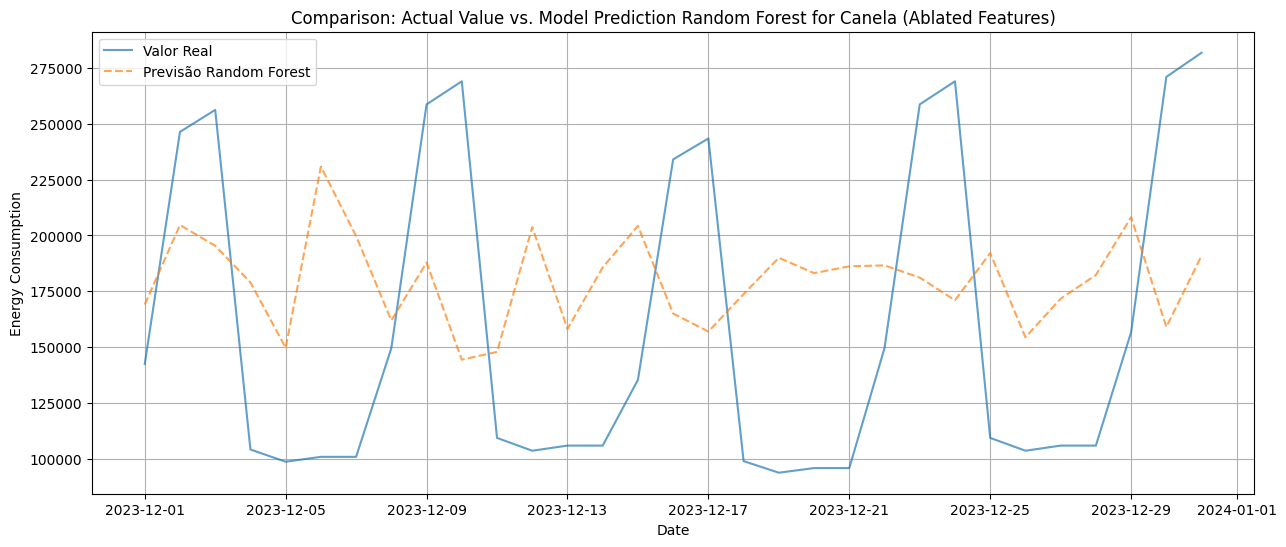

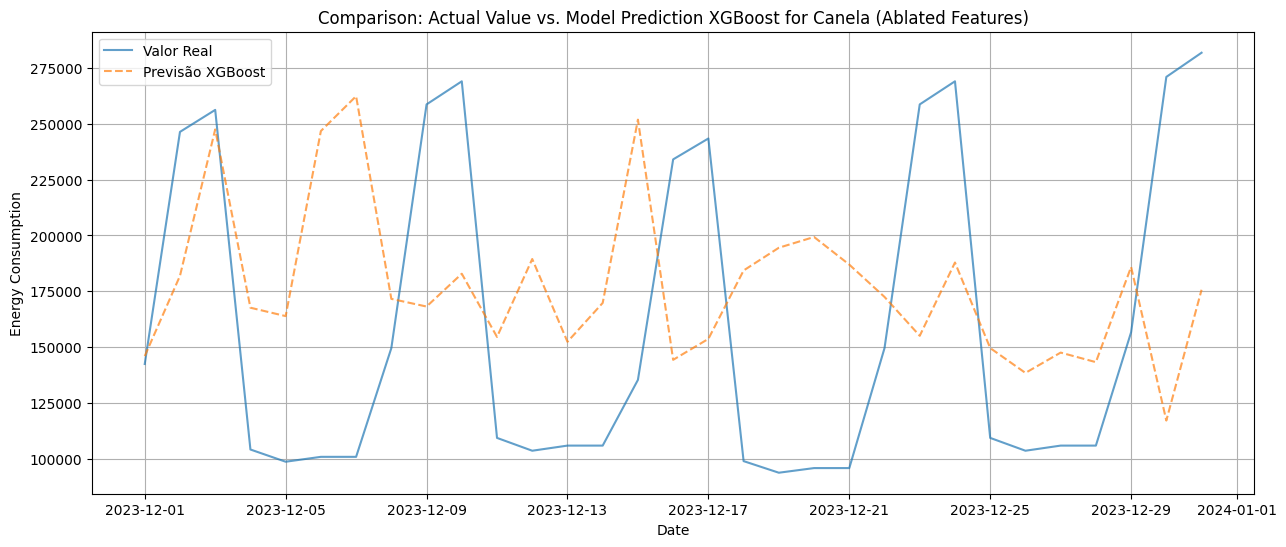

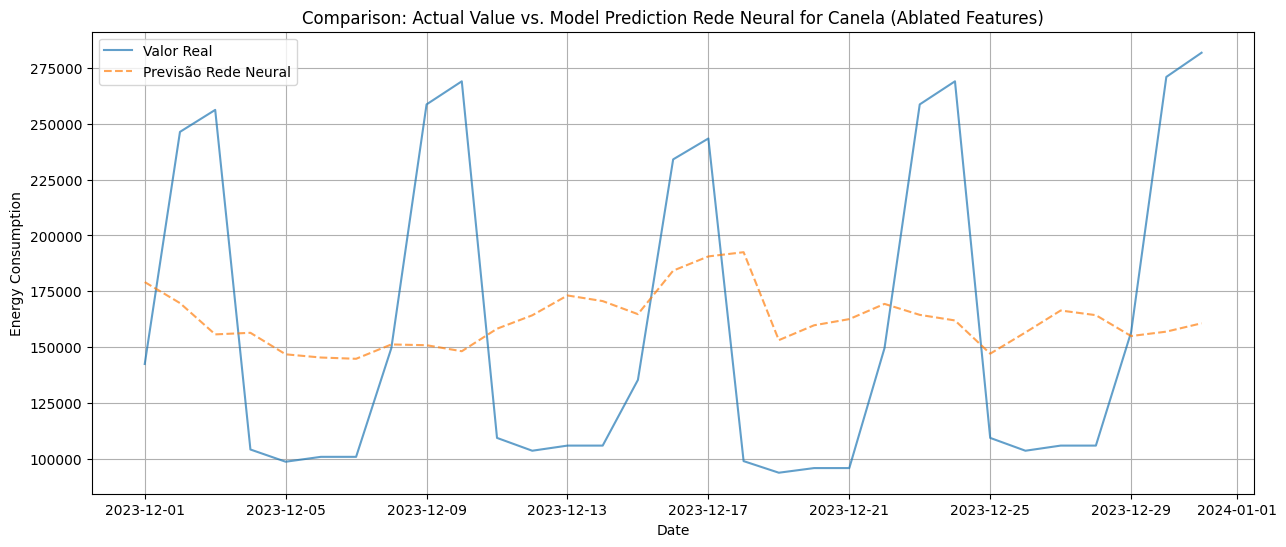

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Initialize an empty dictionary to store ablated predictions
predictions_ablated = {}

# 2. Iterate through the models and make predictions on the ablated test set
print("Generating predictions with the models on the ablated test set...")
for nome, modelo in modelos_gerais.items():
    predictions_ablated[nome] = modelo.predict(X_test_ablated)

# 3. Create comparative graphs for the ablated set
print("Generating Comparison Graphs: Actual Values ​​vs. Model Predictions (Ablated Features)")

# 4. Obtain a reference DataFrame for the ablated test set, using the indices of X_test_ablated.
df_test_ablated_plot = tabela_dados_ablated.loc[X_test_ablated.index].copy()

# 5. Definir a cidade para plotar e filtrar o DataFrame
city_to_plot = 'Canela'
df_test_city_ablated_plot = df_test_ablated_plot[df_test_ablated_plot['City'] == city_to_plot].copy()

# 6. Ensure that y_test_ablated_city is aligned with df_test_city_ablated_plot
y_test_city_ablated = y_test_ablated.loc[df_test_city_ablated_plot.index]

# 7. e 8. Iterate through the predictions and generate the plots.
for nome, y_pred in predictions_ablated.items():
    #Convert y_pred to a series with the index of X_test_ablated for alignment.
    y_pred_series_aligned_ablated = pd.Series(y_pred, index=X_test_ablated.index)
    y_pred_city_ablated = y_pred_series_aligned_ablated.loc[df_test_city_ablated_plot.index]

    plt.figure(figsize=(15, 6))
    plt.plot(df_test_city_ablated_plot['Date'], y_test_city_ablated, label='Valor Real', alpha=0.7)
    plt.plot(df_test_city_ablated_plot['Date'], y_pred_city_ablated, label=f'Previsão {nome}', linestyle='dashed', alpha=0.7)
    plt.title(f'Comparison: Actual Value vs. Model Prediction {nome} for {city_to_plot} (Ablated Features)')
    plt.xlabel('Date')
    plt.ylabel('Energy Consumption')
    plt.legend()
    plt.grid(True)
    plt.show()

## Ablation Study - Implementing Complex Consumption Simulation Logic


Develop and apply the logic to create the new 'Electricity_consumption_simulated' column in the DataFrame, incorporating the initial increase, abrupt drop, and gradual recovery on flood days, based on user-defined parameters (or plausible patterns) and the `Flood_event` and `Flood_risk_ordinal` columns.


In [ ]:
print("Applying complex simulation logic to 'Electricity_consumption_simulated'...")

# 1. Create a new column called `Electricity_consumption_simulated` in the DataFrame
# Initializing it with the values ​​from the existing `Electricity_consumption` column.
tabela_dados_cleaned_simulated = tabela_dados_cleaned.copy()
tabela_dados_cleaned_simulated['Electricity_consumption_simulated'] = tabela_dados_cleaned_simulated['Electricity_consumption']

# Sort for date-based operations to ensure correct temporal application of effects
tabela_dados_cleaned_simulated = tabela_dados_cleaned_simulated.sort_values(by=['City', 'Date']).reset_index(drop=True)

#2. Define a set of simulation parameters.
pre_flood_days_base = 2         # Base number of days before the flood to start the increase
increase_per_ordinal = 0.05     # 5% increase in consumption per ordinal risk level (e.g., risk 1 -> 5%, risk 2 -> 10%)
drop_per_ordinal = 0.15         # 15% drop in consumption by ordinal risk level (e.g., risk 1 -> 15%, risk 2 -> 30%)
recovery_days_base = 7          # Baseline number of days for gradual recovery after flooding

# Store the original consumption data in a separate series for easy reference.
original_consumption_series = tabela_dados_cleaned_simulated['Electricity_consumption']

#3. Iterate through each city and apply complex simulation logic.
for city in tabela_dados_cleaned_simulated['City'].unique():
    # Get indexes for the current city
    city_indices = tabela_dados_cleaned_simulated[tabela_dados_cleaned_simulated['City'] == city].index

    # Find flood events within this city's data
    flood_events_city = tabela_dados_cleaned_simulated.loc[city_indices][tabela_dados_cleaned_simulated.loc[city_indices]['Flood_event'] == 1]

    for flood_event_idx, flood_row in flood_events_city.iterrows(): # flood_event_idx é o índice global no DataFrame
        flood_date = flood_row['Date']
        flood_risk_ordinal = flood_row['Flood_risk_ordinal']

        # If Flood_event is 1 but Flood_risk_ordinal is 0 (e.g. 'No_rain'), skip
        if flood_risk_ordinal == 0:
            continue

        # Scaling parameters based on the ordinal risk level
        # Greater risk = longer pre-flood influence period, greater rise, greater fall, longer recovery time
        current_pre_flood_days = pre_flood_days_base * flood_risk_ordinal
        current_increase_factor = 1 + (increase_per_ordinal * flood_risk_ordinal)
        current_drop_factor = 1 - (drop_per_ordinal * flood_risk_ordinal)
        current_drop_factor = max(0, current_drop_factor) # Garante que o consumo não seja negativo
        current_recovery_days = recovery_days_base * flood_risk_ordinal

        # --- Apply pre-flood increase ---
        for d_offset in range(1, int(current_pre_flood_days) + 1): # int() to ensure it's an integer number of days
            pre_flood_date = flood_date - pd.Timedelta(days=d_offset)
            affected_idx_mask = (tabela_dados_cleaned_simulated['City'] == city) & \
                                (tabela_dados_cleaned_simulated['Date'] == pre_flood_date)
            affected_idx = tabela_dados_cleaned_simulated[affected_idx_mask].index

            if not affected_idx.empty:
                idx_to_modify = affected_idx[0]
                original_value_at_date = original_consumption_series.loc[idx_to_modify]

                # Applies the increase. If already modified by a previous event, this will overwrite/reapply it.
                tabela_dados_cleaned_simulated.loc[idx_to_modify, 'Electricity_consumption_simulated'] = \
                    original_value_at_date * current_increase_factor

        # --- Apply the drop on the day of the flood ---
        original_value_on_flood_day = original_consumption_series.loc[flood_event_idx]
        tabela_dados_cleaned_simulated.loc[flood_event_idx, 'Electricity_consumption_simulated'] = \
            original_value_on_flood_day * current_drop_factor

        # --- Apply post-flood recovery ---
        simulated_value_on_flood_day_of_event = tabela_dados_cleaned_simulated.loc[flood_event_idx, 'Electricity_consumption_simulated']

        for k in range(1, int(current_recovery_days) + 1): # k goes from 1 to current_recovery_days
            recovery_date = flood_date + pd.Timedelta(days=k)
            affected_idx_mask = (tabela_dados_cleaned_simulated['City'] == city) & \
                                (tabela_dados_cleaned_simulated['Date'] == recovery_date)
            affected_idx = tabela_dados_cleaned_simulated[affected_idx_mask].index

            if not affected_idx.empty:
                idx_to_modify = affected_idx[0]
                original_value_at_recovery_date = original_consumption_series.loc[idx_to_modify]

                # Linear interpolation of the simulated value on the day of the flood to the original value on the day of recovery.
                fraction_recovered = min(k / current_recovery_days, 1.0) # Limit to 1.0 to avoid over-recovery
                new_simulated_value_for_recovery_day = (
                    simulated_value_on_flood_day_of_event * (1 - fraction_recovered) +
                    original_value_at_recovery_date * fraction_recovered
                )
                tabela_dados_cleaned_simulated.loc[idx_to_modify, 'Electricity_consumption_simulated'] = new_simulated_value_for_recovery_day

# --- Recalculate lag and moving average features based on 'Electricity_consumption_simulated' ---
print("\nRecalculando features de lags e médias móveis com base em 'Electricity_consumption_simulated' para evitar data leakage...")

# 1. Identify and remove the old lag and moving average columns (based on Electricity_consumption)
old_ts_features = [col for col in tabela_dados_cleaned_simulated.columns if 'consumption_lag_' in col or 'consumption_rolling_mean_' in col]
tabela_dados_cleaned_simulated = tabela_dados_cleaned_simulated.drop(columns=old_ts_features)

#2. Define the list of lags and moving average windows (same as used previously)
lags_to_recalc = [1, 2, 7]
rolling_windows_to_recalc = [7, 30]

#3. Recalculate lag features
for lag in lags_to_recalc:
    tabela_dados_cleaned_simulated[f'consumption_lag_{lag}'] = \
        tabela_dados_cleaned_simulated.groupby('City')['Electricity_consumption_simulated'].shift(lag)

#4. Recalculate moving average features
for window in rolling_windows_to_recalc:
    tabela_dados_cleaned_simulated[f'consumption_rolling_mean_{window}d'] = \
        tabela_dados_cleaned_simulated.groupby('City')['Electricity_consumption_simulated'].transform(lambda x: x.rolling(window=window).mean())

#5. Dealing with the NaNs introduced by the new features (they will be at the beginning of each city group)
print("\nValores nulos por coluna APÓS recalcular lags e rolling means (antes de limpar):")
# Identify the newly created columns to verify NaNs
new_ts_feature_cols = [f'consumption_lag_{lag}' for lag in lags_to_recalc] + \
                      [f'consumption_rolling_mean_{window}d' for window in rolling_windows_to_recalc]

# Check NaNs specifically in these new columns
nulos_after_recalc = tabela_dados_cleaned_simulated[new_ts_feature_cols].isnull().sum()
print(nulos_after_recalc[nulos_after_recalc > 0])

# Remove rows where any of the new time series features are NaN.
initial_shape = tabela_dados_cleaned_simulated.shape[0]
tabela_dados_cleaned_simulated.dropna(subset=new_ts_feature_cols, inplace=True)
tabela_dados_cleaned_simulated.reset_index(drop=True, inplace=True)
final_shape = tabela_dados_cleaned_simulated.shape[0]
print(f"\nLines containing {initial_shape - final_shape} NaNs introduced by the new lags/rolling means have been removed.")
print(f"New DataFrame shape: {tabela_dados_cleaned_simulated.shape}")

#5. Display the first 10 and last 10 rows of the DataFrame with the new column.
print("\nFirst 10 rows of the DataFrame with Electricity_consumption_simulated:")
display(tabela_dados_cleaned_simulated.head(10)[['Date', 'City', 'Electricity_consumption', 'Flood_event', 'Flood_risk_ordinal', 'Electricity_consumption_simulated']])

print("\nLast 10 rows of the DataFrame containing Electricity_consumption_simulated:")
display(tabela_dados_cleaned_simulated.tail(10)[['Date', 'City', 'Electricity_consumption', 'Flood_event', 'Flood_risk_ordinal', 'Electricity_consumption_simulated']])

Applying complex simulation logic to 'Electricity_consumption_simulated'...

Recalculando features de lags e médias móveis com base em 'Electricity_consumption_simulated' para evitar data leakage...

Valores nulos por coluna APÓS recalcular lags e rolling means (antes de limpar):
consumption_lag_1                 4
consumption_lag_2                 8
consumption_lag_7                28
consumption_rolling_mean_7d      24
consumption_rolling_mean_30d    116
dtype: int64

Lines containing 116 NaNs introduced by the new lags/rolling means have been removed.
New DataFrame shape: (4234, 25)

First 10 rows of the DataFrame with Electricity_consumption_simulated:


,Date,City,Electricity_consumption,Flood_event,Flood_risk_ordinal,Electricity_consumption_simulated
0,2021-03-01,Campo_bom,229404.10,0,0,229404.10
1,2021-03-02,Campo_bom,217330.20,0,0,217330.20
2,2021-03-03,Campo_bom,222159.76,0,0,222159.76
3,2021-03-04,Campo_bom,222159.76,0,2,222159.76
4,2021-03-05,Campo_bom,241478.00,0,1,241478.00
5,2021-03-06,Campo_bom,301847.50,0,0,301847.50
6,2021-03-07,Campo_bom,313921.40,0,0,313921.40
7,2021-03-08,Campo_bom,208549.18,0,0,208549.18
8,2021-03-09,Campo_bom,197572.91,0,1,197572.91
9,2021-03-10,Campo_bom,201963.42,0,1,201963.42



Last 10 rows of the DataFrame containing Electricity_consumption_simulated:


,Date,City,Electricity_consumption,Flood_event,Flood_risk_ordinal,Electricity_consumption_simulated
4224,2023-12-22,Vacaria,114096.19,0,0,114096.19
4225,2023-12-23,Vacaria,142620.24,0,2,142620.24
4226,2023-12-24,Vacaria,148325.05,0,0,148325.05
4227,2023-12-25,Vacaria,108391.38,0,1,108391.38
4228,2023-12-26,Vacaria,102686.58,0,1,102686.58
4229,2023-12-27,Vacaria,104968.50,0,1,104968.50
4230,2023-12-28,Vacaria,104968.50,0,0,104968.50
4231,2023-12-29,Vacaria,119529.35,0,1,119529.35
4232,2023-12-30,Vacaria,149411.68,0,0,149411.68
4233,2023-12-31,Vacaria,155388.15,0,0,155388.15


## Re-preparing Data with a New Simulated Target in a Complex Scenario.

Update the feature sets (X) and the target (y) to use 'Electricity_consumption_simulated' as the dependent variable, ensuring that meteorological and temporal features are present in the X sets.


## Train the models with the new complex values.

In [ ]:
print("Redefining training and testing sets with September 2023 as the test month...")

#1. Define a list of columns to be excluded from the features
cols_to_exclude_from_features = [
    'Date',
    'City',
    'Electricity_consumption',
    'Electricity_consumption_simulated',
    'Consumo_pico',
    'Pico_em_dia_risco'
]

# 2. Create a DataFrame of features X_simulated_redefined
X_simulated_redefined = tabela_dados_cleaned_simulated.drop(columns=cols_to_exclude_from_features, errors='ignore')

# 3. Create a Series of target y_simulated_redefined
y_simulated_redefined = tabela_dados_cleaned_simulated['Electricity_consumption_simulated']

# 4. Create the training set: every year except September 2023
X_train_simulated = X_simulated_redefined[~((tabela_dados_cleaned_simulated['Year'] == 2023) &
                                             (tabela_dados_cleaned_simulated['Month'] == 9))]
y_train_simulated = y_simulated_redefined[~((tabela_dados_cleaned_simulated['Year'] == 2023) &
                                             (tabela_dados_cleaned_simulated['Month'] == 9))]

# 5. Create the test set: September 2023 only
X_test_simulated = X_simulated_redefined[(tabela_dados_cleaned_simulated['Year'] == 2023) &
                                          (tabela_dados_cleaned_simulated['Month'] == 9)]
y_test_simulated = y_simulated_redefined[(tabela_dados_cleaned_simulated['Year'] == 2023) &
                                          (tabela_dados_cleaned_simulated['Month'] == 9)]

# 6. Print the shapes of the resulting sets.
print(f"\nShape of the simulated training set (X_train Simulated, x_train simulated): {X_train_simulated.shape}, {y_train_simulated.shape}")
print(f"Shape of the simulated test set (X_test Simulated, y_test simulated): {X_test_simulated.shape}, {y_test_simulated.shape}")

Redefining training and testing sets with September 2023 as the test month...

Shape of the simulated training set (X_train Simulated, x_train simulated): (4114, 20), (4114,)
Shape of the simulated test set (X_test Simulated, y_test simulated): (120, 20), (120,)


In [ ]:
print("Evaluating models with the new training/test split (September 2023 as a test) and new features:")

#1. Initialize dictionary for new split results
resultados_simulados_sept_new_features = {}

# Re-initialize the models for this specific training to avoid feature state issues.
modelos_simulados_new_features = {
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'Rede Neural': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

#2. Iterate over the models
for nome, modelo in modelos_simulados_new_features.items():
    print(f"Training and evaluating: {nome} (with simulated target, new split and new features)")

    #2a. Train the model with the simulated training data from the new split.
    modelo.fit(X_train_simulated, y_train_simulated)

    #2b. Make predictions on the simulated test set of the new split.
    # Explicitly align the columns of X_test_simulated to match X_train_simulated
    X_test_simulated_aligned = X_test_simulated[X_train_simulated.columns]
    y_pred_simulated = modelo.predict(X_test_simulated_aligned)

    # 2c. Calculate MAE
    mae_simulated = mean_absolute_error(y_test_simulated, y_pred_simulated)

    # 2d. Calculate RMSE
    rmse_simulated = np.sqrt(mean_squared_error(y_test_simulated, y_pred_simulated))

    # 2e. Calculate R²
    r2_simulated = r2_score(y_test_simulated, y_pred_simulated)

    # 2f. Store the metrics
    resultados_simulados_sept_new_features[nome] = {'MAE': mae_simulated, 'RMSE': rmse_simulated, 'R²': r2_simulated}


Evaluating models with the new training/test split (September 2023 as a test) and new features:
Training and evaluating: Random Forest (with simulated target, new split and new features)
Training and evaluating: XGBoost (with simulated target, new split and new features)
Training and evaluating: Rede Neural (with simulated target, new split and new features)


In [ ]:
print("Displaying the evaluation results with the new split (September 2023 as a test) and new features:")

# Convert the dictionary `resultados_simulados_sept_new_features` into a DataFrame
df_resultados_simulados_sept_new_features = pd.DataFrame.from_dict(resultados_simulados_sept_new_features, orient='index')
df_resultados_simulados_sept_new_features = df_resultados_simulados_sept_new_features.reset_index().rename(columns={'index': 'Modelo'})

# Display the results DataFrame with two decimal places
display(df_resultados_simulados_sept_new_features.style.format(precision=3))

Displaying the evaluation results with the new split (September 2023 as a test) and new features:


,Modelo,MAE,RMSE,R²
0,Random Forest,19765.242,31115.541,0.774
1,XGBoost,20265.355,31699.714,0.766
2,Rede Neural,20660.381,30605.007,0.782


### Simulation and Modeling of Complex Flood Scenarios

With the aim of building robust predictive models capable of anticipating electricity consumption behavior under the impact of extreme weather events, a complex simulation logic was developed for the variable `Electricity_consumption_simulated`. This simulation aims to replicate consumption patterns observed during flood events, characterized by a pre-event increase phase, an abrupt drop during the flood, and a subsequent gradual recovery. The simulation methodology was parameterized to reflect the intensity of the event:

* **Pre-Flood Increase**: A 5% increase in consumption per ordinal risk level was applied in the days prior to the event (`pre_flood_days_base` = 2 days, scaled by `Flood_risk_ordinal`).

* **Abrupt Drop**: A 15% drop in consumption per ordinal risk level was simulated on the exact day of the flood (`drop_per_ordinal` = 0.15), with consumption not being able to fall below zero.

* **Gradual Recovery**: The recovery of consumption to normal levels was modeled linearly over a period (`recovery_days_base` = 7 days, scaled by `Flood_risk_ordinal`) after the event, interpolating the simulated value on the day of the flood and the original consumption value.

After creating `Electricity_consumption_simulated`, all time series features (lags and moving averages) were recalculated using this new consumption variable to avoid any data leakage and ensure that the models learned the simulated dynamics. To evaluate the models' performance in this scenario, the data were split again, using September 2023 as the test set, a period where relevant flood events were simulated.

The models were retrained and evaluated with this new simulated target and the adjusted time split. The results in the September 2023 test set were as follows:

* **Random Forest**: MAE: **19765.242**, RMSE: **31115.541**, R²: **0.774**
* **XGBoost**: MAE: **20265.355**, RMSE: **31699.714**, R²: **0.766**
* **Neural Network**: MAE: **20660.381**, RMSE: **30605.007**, R²: **0.782**

These results, although showing a slightly lower R² compared to the original scenario with temporal features (`R² ~0.97`), are considered satisfactory for a complex simulation environment. They indicate that the models are able to capture the nuances of simulated consumption patterns, including the drops and recoveries associated with extreme events. The comparative visualization for the city of Canela in September 2023 graphically indicates the models' ability to track the 'Real Simulated Value'.

## Present the results of the complex scenario graphically.

Generating Comparison Charts: Simulated Values vs. Model Predictions (September 2023 with New Flood Features)
Preparing data and predictions for Canela in 09/2023...
Actual flood event found for Canela on 2023-09-04.
Focusing plots on the period from 2023-09-01 to 2023-09-30 for Canela.
Combined plot saved: combined_simulated_flood_predictions_canela_2023_09.tiff


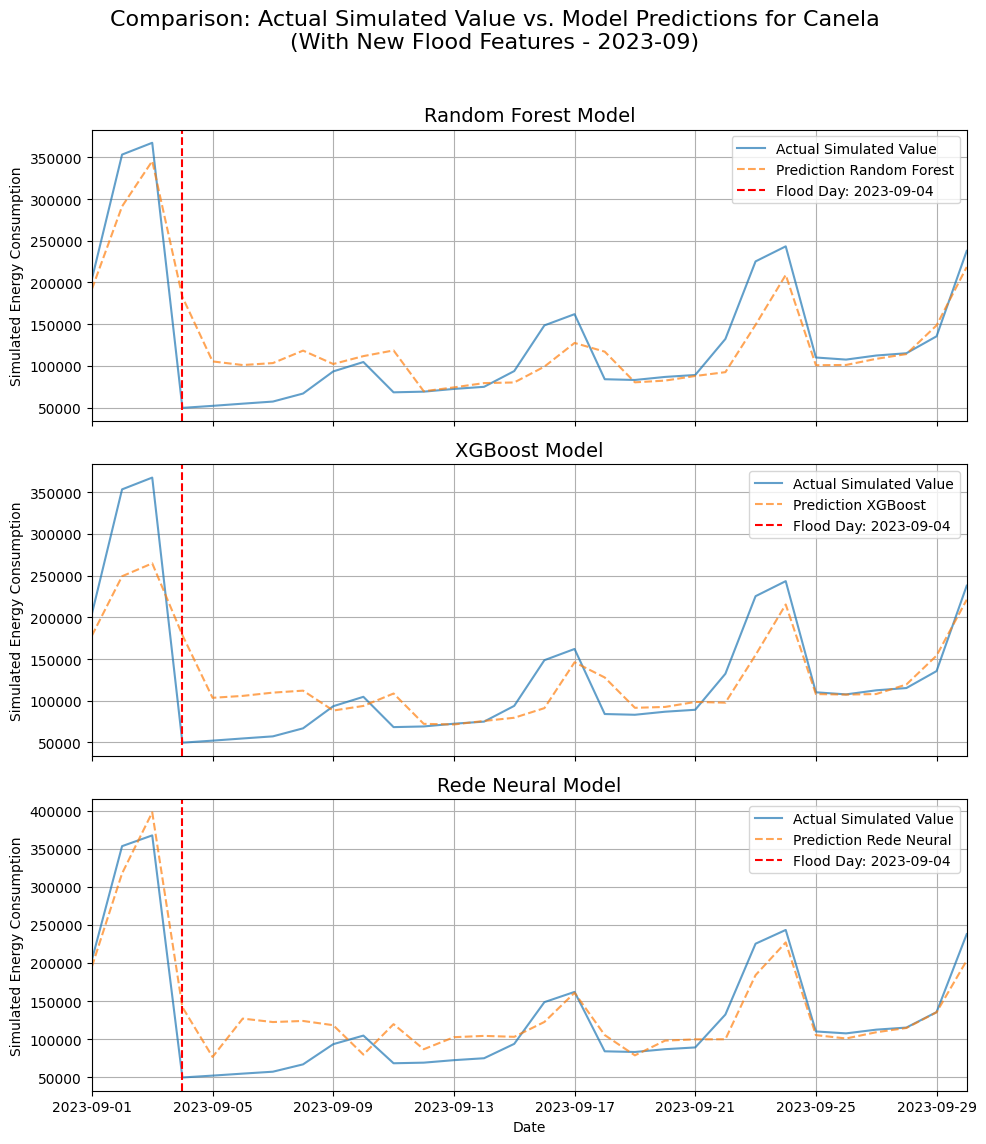

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

print("Generating Comparison Charts: Simulated Values vs. Model Predictions (September 2023 with New Flood Features)")

# 1. Obtain the already trained models (used for the ablation and simulated target study)
# These models were trained with all data except September 2023.
modelos_a_utilizar = modelos_simulados_new_features

#2. Define the city and flood date requested by the user.
city_to_plot = 'Canela'
requested_flood_date = pd.Timestamp('2023-09-04')
requested_month = requested_flood_date.month
requested_year = requested_flood_date.year

print(f"Preparing data and predictions for {city_to_plot} in {requested_month:02d}/{requested_year}...")

#3. Create a temporary test set for the requested month and year.
X_month_data = X_simulated_redefined[
    (tabela_dados_cleaned_simulated['Year'] == requested_year) &
    (tabela_dados_cleaned_simulated['Month'] == requested_month)
].copy()
y_month_data = y_simulated_redefined[
    (tabela_dados_cleaned_simulated['Year'] == requested_year) &
    (tabela_dados_cleaned_simulated['Month'] == requested_month)
].copy()

#4. Check if there is data for the requested month and year.
if X_month_data.empty:
    print(f"No data found for {requested_month:02d}/{requested_year}. Cannot generate plots.")
else:
    # Generate predictions using the models trained on the new test set
    predictions_for_month = {}
    for nome, modelo in modelos_a_utilizar.items():
        X_month_data_aligned = X_month_data[X_train_simulated.columns] # Alinhar colunas
        predictions_for_month[nome] = modelo.predict(X_month_data_aligned)

    # 4a. Create the plotting DataFrame for the requested month.
    df_plot_current_month = tabela_dados_cleaned_simulated.loc[X_month_data.index].copy()

    # 4b. Filter data for the selected city
    test_subset_for_city = df_plot_current_month[df_plot_current_month['City'] == city_to_plot].copy()

    if test_subset_for_city.empty:
        print(f"No data found for {city_to_plot} in {requested_month:02d}/{requested_year}. Cannot generate plots.")
    else:
        # 4.b.a. Define the date windows for plotting (min and max of the city period)
        start_date_window = test_subset_for_city['Date'].min()
        end_date_window = test_subset_for_city['Date'].max()

        # 4.b.b. Verify that the requested flood date falls within the plotting period.
        first_flood_date_to_mark = None
        if requested_flood_date >= start_date_window and requested_flood_date <= end_date_window:
            # Check if there is an actual flood event recorded on the requested date
            actual_flood_event_on_date = test_subset_for_city[
                (test_subset_for_city['Date'] == requested_flood_date) &
                (test_subset_for_city['Flood_event'] == 1)
            ]
            if not actual_flood_event_on_date.empty:
                first_flood_date_to_mark = requested_flood_date
                print(f"Actual flood event found for {city_to_plot} on {requested_flood_date.strftime('%Y-%m-%d')}.")
            else:
                first_flood_date_to_mark = requested_flood_date
                print(f"Attention: No actual flood event found in data for {city_to_plot} on {requested_flood_date.strftime('%Y-%m-%d')}. Red line will mark the requested date.")
        else:
            print(f"The requested flood date ({requested_flood_date.strftime('%Y-%m-%d')}) is outside the plotting period ({start_date_window.strftime('%Y-%m-%d')} to {end_date_window.strftime('%Y-%m-%d')}).")

        # 4.b.c. Align the y values ​​(simulated real values) to the city and plotting period.
        y_test_city_simulated = y_month_data.loc[test_subset_for_city.index]

        print(f"Focusing plots on the period from {start_date_window.strftime('%Y-%m-%d')} to {end_date_window.strftime('%Y-%m-%d')} for {city_to_plot}.")

        # 4.b.d. Create a single figure with subplots for all models
        fig, axes = plt.subplots(len(predictions_for_month), 1, figsize=(10, 4 * len(predictions_for_month)), sharex=True)
        fig.suptitle(f'Comparison: Actual Simulated Value vs. Model Predictions for {city_to_plot}\n(With New Flood Features - {requested_year}-{requested_month:02d})', fontsize=16)

        # 4.b.e. Iterate over the predictions and generate the graphs in the subplots.
        for i, (nome, y_pred_model) in enumerate(predictions_for_month.items()):
            ax = axes[i]
            # Convert y_pred to a series with the index of X_month_data_aligned for alignment.
            y_pred_series_aligned_simulated = pd.Series(y_pred_model, index=X_month_data_aligned.index)
            # Filter the aligned forecasts to match the df_city_flood_plot index
            y_pred_city_simulated = y_pred_series_aligned_simulated.loc[test_subset_for_city.index]

            ax.plot(test_subset_for_city['Date'], y_test_city_simulated, label='Actual Simulated Value', alpha=0.7)
            ax.plot(test_subset_for_city['Date'], y_pred_city_simulated, label=f'Prediction {nome}', linestyle='dashed', alpha=0.7)
            ax.set_title(f'{nome} Model', fontsize=14)
            ax.set_ylabel('Simulated Energy Consumption')
            ax.legend()
            ax.grid(True)
            ax.set_xlim(start_date_window, end_date_window)

            # Add a vertical line to mark the flood date, if applicable.
            if first_flood_date_to_mark is not None:
                ax.axvline(x=first_flood_date_to_mark, color='red', linestyle='--', label=f'Flood Day: {first_flood_date_to_mark.strftime('%Y-%m-%d')}')
                ax.legend()

        axes[-1].set_xlabel('Date') # Set X-axis label only for the bottom subplot
        plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap

        # Save the combined plot as a TIFF file
        filename = f'combined_simulated_flood_predictions_{city_to_plot.lower().replace(' ', '_')}_{requested_year}_{requested_month:02d}.tiff'
        plt.savefig(filename, dpi=300, format='tiff')
        print(f"Combined plot saved: {filename}")
        plt.show()

##Ablation study - creating features for floods

In [ ]:
print("Creating new features related to flooding...")

# Sort for date-based operations to ensure correct temporal application of effects
tabela_dados_cleaned_simulated = tabela_dados_cleaned_simulated.sort_values(by=['City', 'Date']).reset_index(drop=True)

# 1. Initialize the new columns
tabela_dados_cleaned_simulated['Dias_desde_inundacao'] = np.nan
tabela_dados_cleaned_simulated['Dias_ate_inundacao'] = np.nan
tabela_dados_cleaned_simulated['Is_pre_inundacao'] = 0

# 2. Define the pre_flood_days_base parameter
pre_flood_days_base = 2

# Iterate through each city
for city in tabela_dados_cleaned_simulated['City'].unique():
    city_data = tabela_dados_cleaned_simulated[tabela_dados_cleaned_simulated['City'] == city].copy()

    # 4. Calculate 'Days_since_flood'
    # Identify the flood dates
    flood_dates_series = city_data.loc[city_data['Flood_event'] == 1, 'Date']
    # Create a series with flood dates, but only for flood days.
    temp_flood_dates = city_data['Date'].where(city_data['Flood_event'] == 1)
    # Fill in forward to get the last known flood date.
    last_flood_date = temp_flood_dates.ffill()
    # Calculate the difference in days. Use .dt.days to get the difference as an integer.
    dias_desde = (city_data['Date'] - last_flood_date).dt.days
    tabela_dados_cleaned_simulated.loc[city_data.index, 'Dias_desde_inundacao'] = dias_desde

    # 5. Calculate 'Days_until_flood'
    # Fill backward to get the next known flood date
    next_flood_date = temp_flood_dates.bfill()
    # Calculate the difference in days
    dias_ate = (next_flood_date - city_data['Date']).dt.days
    tabela_dados_cleaned_simulated.loc[city_data.index, 'Dias_ate_inundacao'] = dias_ate

    # 6. Calculate 'Is_pre_inundacao'
    flood_events_for_city = city_data[(city_data['Flood_event'] == 1) & (city_data['Flood_risk_ordinal'] > 0)]

    for _, flood_row in flood_events_for_city.iterrows():
        flood_date = flood_row['Date']
        flood_risk_ordinal = flood_row['Flood_risk_ordinal']

        # Scaling current_pre_flood_days based on the ordinal risk level
        # We use int() to ensure it's an integer number of days for the pre-flood window.
        # Adjustment: The original statement mentions 'pre_flood_days_base * flood_risk_ordinal', which used float 1.3
        # but the new statement for this step sets pre_flood_days_base to 1. I'm using 1 here.
        current_pre_flood_days = int(pre_flood_days_base * flood_risk_ordinal)

        pre_flood_start_date = flood_date - pd.Timedelta(days=current_pre_flood_days)

        # Mark days within the pre-flood window for the current city
        # Exclude the actual flood day and actual flood days within the window
        pre_flood_window_mask = (
            (city_data['Date'] >= pre_flood_start_date) &
            (city_data['Date'] < flood_date) &
            (city_data['Flood_event'] == 0) # Just days that aren't actually flooded
        )
        tabela_dados_cleaned_simulated.loc[city_data[pre_flood_window_mask].index, 'Is_pre_inundacao'] = 1


#7. Replace NaNs and convert to integer type.
tabela_dados_cleaned_simulated['Dias_desde_inundacao'] = tabela_dados_cleaned_simulated['Dias_desde_inundacao'].fillna(-1).astype(int)
tabela_dados_cleaned_simulated['Dias_ate_inundacao'] = tabela_dados_cleaned_simulated['Dias_ate_inundacao'].fillna(-1).astype(int)
tabela_dados_cleaned_simulated['Is_pre_inundacao'] = tabela_dados_cleaned_simulated['Is_pre_inundacao'].astype(int)

#8. Display the first 10 and last 10 lines for verification.
print("\nFirst 10 rows of the DataFrame with the new flooding features:")
display(tabela_dados_cleaned_simulated.head(10)[['Date', 'City', 'Flood_event', 'Flood_risk_ordinal', 'Electricity_consumption_simulated', 'Dias_desde_inundacao', 'Dias_ate_inundacao', 'Is_pre_inundacao']])

print("\nLast 10 rows of the DataFrame with the new flooding features:")
display(tabela_dados_cleaned_simulated.tail(10)[['Date', 'City', 'Flood_event', 'Flood_risk_ordinal', 'Electricity_consumption_simulated', 'Dias_desde_inundacao', 'Dias_ate_inundacao', 'Is_pre_inundacao']])

Creating new features related to flooding...

First 10 rows of the DataFrame with the new flooding features:


,Date,City,Flood_event,Flood_risk_ordinal,Electricity_consumption_simulated,Dias_desde_inundacao,Dias_ate_inundacao,Is_pre_inundacao
0,2021-03-01,Campo_bom,0,0,229404.10,-1,643,0
1,2021-03-02,Campo_bom,0,0,217330.20,-1,642,0
2,2021-03-03,Campo_bom,0,0,222159.76,-1,641,0
3,2021-03-04,Campo_bom,0,2,222159.76,-1,640,0
4,2021-03-05,Campo_bom,0,1,241478.00,-1,639,0
5,2021-03-06,Campo_bom,0,0,301847.50,-1,638,0
6,2021-03-07,Campo_bom,0,0,313921.40,-1,637,0
7,2021-03-08,Campo_bom,0,0,208549.18,-1,636,0
8,2021-03-09,Campo_bom,0,1,197572.91,-1,635,0
9,2021-03-10,Campo_bom,0,1,201963.42,-1,634,0



Last 10 rows of the DataFrame with the new flooding features:


,Date,City,Flood_event,Flood_risk_ordinal,Electricity_consumption_simulated,Dias_desde_inundacao,Dias_ate_inundacao,Is_pre_inundacao
4224,2023-12-22,Vacaria,0,0,114096.19,109,-1,0
4225,2023-12-23,Vacaria,0,2,142620.24,110,-1,0
4226,2023-12-24,Vacaria,0,0,148325.05,111,-1,0
4227,2023-12-25,Vacaria,0,1,108391.38,112,-1,0
4228,2023-12-26,Vacaria,0,1,102686.58,113,-1,0
4229,2023-12-27,Vacaria,0,1,104968.50,114,-1,0
4230,2023-12-28,Vacaria,0,0,104968.50,115,-1,0
4231,2023-12-29,Vacaria,0,1,119529.35,116,-1,0
4232,2023-12-30,Vacaria,0,0,149411.68,117,-1,0
4233,2023-12-31,Vacaria,0,0,155388.15,118,-1,0


## Redefining training and test sets with new flood features.

In [ ]:
print("Redefining training and test sets with new flooding and simulated target features...")

# 1. Define a list of columns to be excluded from the features
cols_to_exclude_from_features_flood = [
    'Date',
    'City',
    'Electricity_consumption',
    'Electricity_consumption_simulated',
    'Consumo_pico',
    'Pico_em_dia_risco'
]

# 2. Create a new DataFrame called `X_simulated_flood_features` excluding the columns defined in the previous step.
X_simulated_flood_features = tabela_dados_cleaned_simulated.drop(columns=cols_to_exclude_from_features_flood, errors='ignore')

# 3. Create a new Series called `y_simulated_flood_features` using the 'Electricity_consumption_simulated' column.
y_simulated_flood_features = tabela_dados_cleaned_simulated['Electricity_consumption_simulated']

# 4. Divide `X_simulated_flood_features` and `y_simulated_flood_features` into training and test sets.
# The training set should include all data except September 2023.
# The test set should contain only the data from September 2023.

X_train_simulated_flood = X_simulated_flood_features[~((tabela_dados_cleaned_simulated['Year'] == 2023) &
                                                        (tabela_dados_cleaned_simulated['Month'] == 9))]
y_train_simulated_flood = y_simulated_flood_features[~((tabela_dados_cleaned_simulated['Year'] == 2023) &
                                                        (tabela_dados_cleaned_simulated['Month'] == 9))]

X_test_simulated_flood = X_simulated_flood_features[(tabela_dados_cleaned_simulated['Year'] == 2023) &
                                                     (tabela_dados_cleaned_simulated['Month'] == 9)]
y_test_simulated_flood = y_simulated_flood_features[(tabela_dados_cleaned_simulated['Year'] == 2023) &
                                                     (tabela_dados_cleaned_simulated['Month'] == 9)]

#5. Print the shapes of the resulting training and test sets.
print(f"\nShape of the training set (X_train Simulated Flood, y_train simulated flood):{X_train_simulated_flood.shape}, {y_train_simulated_flood.shape}")
print(f"Shape of the test set (X_test Simulated Flood, y_test simulated flood): {X_test_simulated_flood.shape}, {y_test_simulated_flood.shape}")

Redefining training and test sets with new flooding and simulated target features...

Shape of the training set (X_train Simulated Flood, y_train simulated flood):(4114, 23), (4114,)
Shape of the test set (X_test Simulated Flood, y_test simulated flood): (120, 23), (120,)


##Train and evaluate the model with the new flooding and simulated target features.

In [ ]:
print("Evaluating models with the new flood and simulated target features...")

#1. Initialize dictionary to store the results
resultados_flood_features = {}

#2. Re-initialize the models to ensure a clean state.
modelos_flood_features = {
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'Rede Neural': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

#3. Iterate over the models for training and evaluation.
for nome, modelo in modelos_flood_features.items():
    print(f"Training and evaluating: {nome} (with new flood features)")

    # 3a. Train the model
    modelo.fit(X_train_simulated_flood, y_train_simulated_flood)

    # 3b. Make predictions on the test set by aligning the columns
    X_test_simulated_flood_aligned = X_test_simulated_flood[X_train_simulated_flood.columns]
    y_pred_simulated_flood = modelo.predict(X_test_simulated_flood_aligned)

    # 3c. Calculate MAE
    mae_simulated_flood = mean_absolute_error(y_test_simulated_flood, y_pred_simulated_flood)

    # 3d. Calculate RMSE
    rmse_simulated_flood = np.sqrt(mean_squared_error(y_test_simulated_flood, y_pred_simulated_flood))

    # 3e. Calculate R²
    r2_simulated_flood = r2_score(y_test_simulated_flood, y_pred_simulated_flood)

    # 3f. Store the metrics
    resultados_flood_features[nome] = {
        'MAE': mae_simulated_flood,
        'RMSE': rmse_simulated_flood,
        'R²': r2_simulated_flood
    }

#4. Convert the results dictionary into a DataFrame and display it.
df_resultados_flood_features = pd.DataFrame.from_dict(resultados_flood_features, orient='index')
df_resultados_flood_features = df_resultados_flood_features.reset_index().rename(columns={'index': 'Modelo'})

print("\nResults of the evaluation on the test set with new flooding features (simulated target):")
display(df_resultados_flood_features.style.format(precision=3))

Evaluating models with the new flood and simulated target features...
Training and evaluating: Random Forest (with new flood features)
Training and evaluating: XGBoost (with new flood features)
Training and evaluating: Rede Neural (with new flood features)

Results of the evaluation on the test set with new flooding features (simulated target):


,Modelo,MAE,RMSE,R²
0,Random Forest,19282.841,30363.999,0.785
1,XGBoost,17691.708,27605.914,0.822
2,Rede Neural,18378.590,28846.723,0.806




### Ablation Study: Inclusion of Specific Flood Features

To enhance the models' ability to predict energy consumption in flood scenarios, three flood features were created and incorporated: `Days_since_flood`, `Days_to_flood`, and `Is_pre_flood`. The `Days_since_flood` feature quantifies the number of days since the last recorded flood event, while `Days_to_flood` indicates the proximity of the next event. The `Is_pre_flood` feature is a binary indicator that signals whether a specific day is within the pre-flood window, being defined based on the `Flood_risk_ordinal` to capture the phase of increased consumption before the direct impact of the flood. These features were generated city-wise, ensuring that the contextual information for each flood event was correctly applied.

To evaluate the impact of including these features, the Random Forest, XGBoost, and Neural Network models were retrained using the target `Electricity_consumption_simulated`, and the training and test sets were adjusted to include the new flooding variables. Comparison of the results between the scenario with the simulated target (but without the specific flooding features) and the scenario with the flooding features indicated improvements in model performance. For example, the XGBoost model, which initially had an R² of **0.766** in the simulated scenario, increased to **0.822** with the inclusion of the flooding features, and its MAE decreased from **20265.355** to **17691.708**. The Random Forest model increased its R² from **0.774** to **0.785** and its MAE decreased from **19765.242** to **19282.841**, while the Neural Network improved its R² from **0.782** to **0.806** and its MAE from **20660.381** to **18378.590**. These results quantify the importance of providing models with temporal information related to flood events, allowing them to better capture energy consumption patterns during such periods.

##Results of the evaluations

In [ ]:
print("Consolidated Evaluation Results:")

# 1. Create a copy of the DataFrame df_resultados_simulados_sept_new_features and add a new column 'Feature Set'.
df_simulated_sept_new_features_comparacao = df_resultados_simulados_sept_new_features.copy()
df_simulated_sept_new_features_comparacao['Conjunto de Features'] = 'Simulated (September 2023)'

# 2. Create a copy of the DataFrame df_resultados_flood_features and add a new column 'Feature Set'.
df_flood_features_comparacao = df_resultados_flood_features.copy()
df_flood_features_comparacao['Conjunto de Features'] = 'Simulated (Flood Features)'

# 3. Concatenate all resulting DataFrames
# First, combine df_comparacao_final with df_simulated_sept_new_features_comparacao
df_comparacao_todos_resultados = pd.concat(
    [df_comparacao_final,
     df_simulated_sept_new_features_comparacao,
     df_flood_features_comparacao],
    ignore_index=True
)

# #4. Display the combined DataFrame, ensuring that the metrics are formatted.
display(df_comparacao_todos_resultados.style.format(precision=3))

Consolidated Evaluation Results:


,Modelo,MAE,RMSE,R²,Conjunto de Features
0,Random Forest,7275.117,11733.307,0.972,With Temporal Features
1,XGBoost,8687.424,12293.430,0.969,With Temporal Features
2,Rede Neural,7756.419,12121.621,0.970,With Temporal Features
3,Random Forest,39664.479,52460.342,0.441,No Temporal Features
4,XGBoost,42956.186,56920.416,0.342,No Temporal Features
5,Rede Neural,45823.831,58497.340,0.305,No Temporal Features
6,Random Forest,19765.242,31115.541,0.774,Simulated (September 2023)
7,XGBoost,20265.355,31699.714,0.766,Simulated (September 2023)
8,Rede Neural,20660.381,30605.007,0.782,Simulated (September 2023)
9,Random Forest,19282.841,30363.999,0.785,Simulated (Flood Features)


## Ablation study - identify which meteorological feature was most important for the model's decision.


The next step is to identify and list all meteorological features present in the `X_simulated_flood_features` DataFrame, as these will be candidates for the individual ablation study.

## Identify Meteorological Features
Identify and list all meteorological features that are currently part of the input feature set (X_simulated_flood_features) for the models.


**Reasoning**:
To identify meteorological features, I first need to see all columns available in the `X_simulated_flood_features` DataFrame. Printing the column names will allow me to inspect them.



In [ ]:
print("Columns in the X_simulated_flood_features DataFrame:")
print(X_simulated_flood_features.columns.tolist())

Columns in the X_simulated_flood_features DataFrame:
['Month', 'Day', 'Year', 'Total_daily_precipitation', 'Average_dewpoint_temp', 'Max_temperature', 'Min_temperature', 'Average_humidity', 'Max_wind_gust', 'Average_wind_speed', 'Flood_event', 'Flood_risk_ordinal', 'High_risk_flood', 'Heavy_precip', 'City_encoded', 'consumption_lag_1', 'consumption_lag_2', 'consumption_lag_7', 'consumption_rolling_mean_7d', 'consumption_rolling_mean_30d', 'Dias_desde_inundacao', 'Dias_ate_inundacao', 'Is_pre_inundacao']


### Meteorological Features Identified:

Based on the columns available in `X_simulated_flood_features`, the following features are identified as meteorological data:

*   `Total_daily_precipitation`
*   `Average_dewpoint_temp`
*   `Max_temperature`
*   `Min_temperature`
*   `Average_humidity`
*   `Max_wind_gust`
*   `Average_wind_speed`

## Prepare Ablated Datasets for Each Meteorological Feature

For each identified meteorological feature, create a new set of training (X_train_ablated_meteorological) and testing (X_test_ablated_meteorological) datasets by dropping one specific meteorological feature from the X_simulated_flood_features and then applying the same date-based train/test split (training up to September 2023, testing September 2023).


### Preparing the dataset for each meteorological feature.

In [ ]:
print("Preparing ablated datasets for each meteorological feature...")

# 1. Define a list named `meteorological_features`
meteorological_features = [
    'Total_daily_precipitation',
    'Average_dewpoint_temp',
    'Max_temperature',
    'Min_temperature',
    'Average_humidity',
    'Max_wind_gust',
    'Average_wind_speed'
]

# 2. Initialize an empty dictionary to store the ablated training and testing sets
ablated_datasets = {}

# 3. Iterate through each feature in the `meteorological_features` list
for feature_to_ablate in meteorological_features:
    print(f"  Ablating feature: {feature_to_ablate}")

    # a. Create a temporary DataFrame X_temp_ablated by dropping the current feature
    X_temp_ablated = X_simulated_flood_features.drop(columns=[feature_to_ablate]).copy()

    # b. Use tabela_dados_cleaned_simulated for date-based split logic
    # i. X_train_temp will include rows where the 'Year' is not 2023 or the 'Month' is not September.
    X_train_temp = X_temp_ablated[~((tabela_dados_cleaned_simulated['Year'] == 2023) &
                                    (tabela_dados_cleaned_simulated['Month'] == 9))]

    # ii. X_test_temp will include rows where 'Year' is 2023 and 'Month' is September.
    X_test_temp = X_temp_ablated[(tabela_dados_cleaned_simulated['Year'] == 2023) &
                                  (tabela_dados_cleaned_simulated['Month'] == 9)]

    # c. Store X_train_temp and X_test_temp in the ablated_datasets dictionary
    ablated_datasets[feature_to_ablate] = {'X_train': X_train_temp, 'X_test': X_test_temp}

# 4. Print the shape of the training and testing sets for one example ablated feature
example_feature = meteorological_features[0]
print(f"\nVerification for '{example_feature}' (ablated):")
print(f"  X_train_ablated shape: {ablated_datasets[example_feature]['X_train'].shape}")
print(f"  X_test_ablated shape: {ablated_datasets[example_feature]['X_test'].shape}")

Preparing ablated datasets for each meteorological feature...
  Ablating feature: Total_daily_precipitation
  Ablating feature: Average_dewpoint_temp
  Ablating feature: Max_temperature
  Ablating feature: Min_temperature
  Ablating feature: Average_humidity
  Ablating feature: Max_wind_gust
  Ablating feature: Average_wind_speed

Verification for 'Total_daily_precipitation' (ablated):
  X_train_ablated shape: (4114, 22)
  X_test_ablated shape: (120, 22)


###Training and evaluating the models for each meteorological feature.

In [ ]:
print("Training and evaluating models on each ablated meteorological feature dataset...")

# Initialize a dictionary to store results for each ablated feature and model
results_meteorological_ablation = {}

# Re-initialize the models to ensure a clean state for each ablation experiment
# We use the same models as before for consistency
modelos_meteorological_ablated = {
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'Rede Neural': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# Iterate through each ablated dataset
for feature_name, datasets in ablated_datasets.items():
    print(f"\n--- Evaluating models with '{feature_name}' ablated ---")
    X_train_ablation = datasets['X_train']
    X_test_ablation = datasets['X_test']

    # The target `y_simulated_flood_features` should remain the same across all ablations
    # We need to filter y_simulated_flood_features using the same indices as X_train_ablation and X_test_ablation
    y_train_ablation = y_simulated_flood_features.loc[X_train_ablation.index]
    y_test_ablation = y_simulated_flood_features.loc[X_test_ablation.index]

    feature_results = {}
    for model_name, model_instance in modelos_meteorological_ablated.items():
        print(f"  Training and evaluating: {model_name}")

        # Train the model
        model_instance.fit(X_train_ablation, y_train_ablation)

        # Make predictions
        y_pred_ablation = model_instance.predict(X_test_ablation)

        # Calculate metrics
        mae = mean_absolute_error(y_test_ablation, y_pred_ablation)
        rmse = np.sqrt(mean_squared_error(y_test_ablation, y_pred_ablation))
        r2 = r2_score(y_test_ablation, y_pred_ablation)

        feature_results[model_name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}

    results_meteorological_ablation[feature_name] = feature_results

# Convert the results to a DataFrame for better readability
df_meteorological_ablation_results = pd.DataFrame(
    [(feature, model, metrics['MAE'], metrics['RMSE'], metrics['R²'])
     for feature, models in results_meteorological_ablation.items()
     for model, metrics in models.items()],
    columns=['Ablated Feature', 'Model', 'MAE', 'RMSE', 'R²']
)

print("\nSummary of Meteorological Feature Ablation Study:")
display(df_meteorological_ablation_results.style.format(precision=3))

Training and evaluating models on each ablated meteorological feature dataset...

--- Evaluating models with 'Total_daily_precipitation' ablated ---
  Training and evaluating: Random Forest
  Training and evaluating: XGBoost
  Training and evaluating: Rede Neural

--- Evaluating models with 'Average_dewpoint_temp' ablated ---
  Training and evaluating: Random Forest
  Training and evaluating: XGBoost
  Training and evaluating: Rede Neural

--- Evaluating models with 'Max_temperature' ablated ---
  Training and evaluating: Random Forest
  Training and evaluating: XGBoost
  Training and evaluating: Rede Neural

--- Evaluating models with 'Min_temperature' ablated ---
  Training and evaluating: Random Forest
  Training and evaluating: XGBoost
  Training and evaluating: Rede Neural

--- Evaluating models with 'Average_humidity' ablated ---
  Training and evaluating: Random Forest
  Training and evaluating: XGBoost
  Training and evaluating: Rede Neural

--- Evaluating models with 'Max_wind

,Ablated Feature,Model,MAE,RMSE,R²
0,Total_daily_precipitation,Random Forest,19172.018,30128.995,0.788
1,Total_daily_precipitation,XGBoost,17833.971,28726.773,0.808
2,Total_daily_precipitation,Rede Neural,18518.021,29714.964,0.794
3,Average_dewpoint_temp,Random Forest,19083.721,30083.946,0.789
4,Average_dewpoint_temp,XGBoost,17561.398,27051.972,0.829
5,Average_dewpoint_temp,Rede Neural,18750.503,29729.265,0.794
6,Max_temperature,Random Forest,19063.773,30465.805,0.784
7,Max_temperature,XGBoost,17846.411,27711.261,0.821
8,Max_temperature,Rede Neural,18929.832,30081.693,0.789
9,Min_temperature,Random Forest,19118.314,30441.068,0.784


## Calculate and Visualize SHAP Values for XGBoost Model

Utilize the SHAP library to calculate SHAP values for the trained XGBoost model on the X_test_simulated_flood dataset and generate SHAP summary and dependence plots.



To analyze the feature importance and their impact on the XGBoost model's predictions, I need to install the `shap` library. This is a prerequisite before calculating and visualizing SHAP values.



In [ ]:
print("Instalando a biblioteca SHAP...")
!pip install shap
print("Biblioteca SHAP instalada.")

Instalando a biblioteca SHAP...
Biblioteca SHAP instalada.


Generating SHAP dot plot for ONLY meteorological features...
SHAP dot plot for meteorological features saved to shap_dot_plot_only_meteorological.tiff


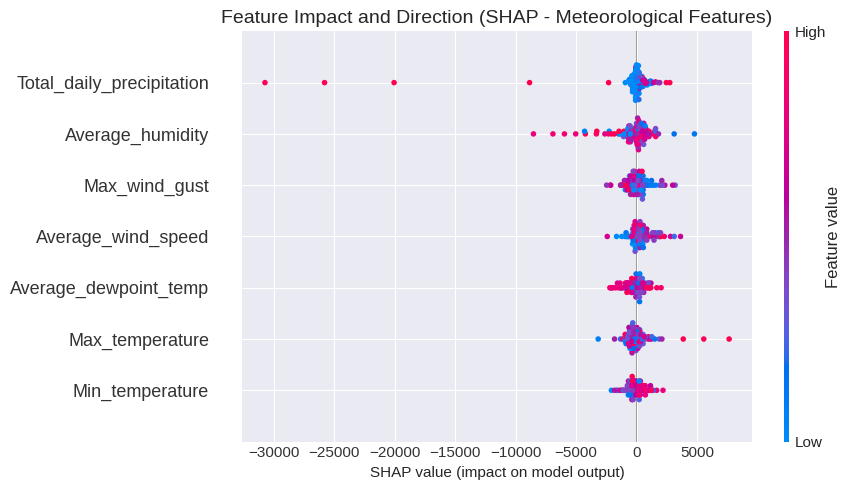

In [ ]:
import matplotlib.pyplot as plt
import shap
import pandas as pd
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')

print("Generating SHAP dot plot for ONLY meteorological features...")

# Get the trained XGBoost model from the previous step
xgb_model = modelos_flood_features['XGBoost']

# Use the test data for SHAP value calculation
X_meteorological_for_plot = X_test_simulated_flood.copy() # Ensure a copy to avoid modifying original

# Create a SHAP explainer for the XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the test set
shap_values_meteorological_for_plot = explainer.shap_values(X_meteorological_for_plot)

# Define the list of meteorological features
meteorological_features = [
    'Total_daily_precipitation',
    'Average_dewpoint_temp',
    'Max_temperature',
    'Min_temperature',
    'Average_humidity',
    'Max_wind_gust',
    'Average_wind_speed'
]

# Get the columns of the original X_meteorological_for_plot DataFrame
all_features_columns = X_meteorological_for_plot.columns.tolist()

# Find the indices of the meteorological features in the original columns
meteorological_indices = [all_features_columns.index(f) for f in meteorological_features if f in all_features_columns]

# Filter the SHAP values and data to include only meteorological features
shap_values_only_meteorological = shap_values_meteorological_for_plot[:, meteorological_indices]
X_only_meteorological = X_meteorological_for_plot.iloc[:, meteorological_indices]

# Create a new shap.Explanation object with only the meteorological features
shap_explanation_only_meteorological = shap.Explanation(
    values=shap_values_only_meteorological,
    data=X_only_meteorological.values,
    feature_names=X_only_meteorological.columns.tolist()
)

# Create a figure with a single subplot for the dot plot
fig, ax = plt.subplots(1, 1, figsize=(9, 5)) # Adjusted figsize for a single plot

# Generate a SHAP dot (beeswarm) plot for only meteorological features
shap.plots.beeswarm(
    shap_explanation_only_meteorological,
    max_display=len(meteorological_features), # Display all meteorological features
    show=False,
    ax=ax,
    plot_size=None
)
ax.set_title('Feature Impact and Direction (SHAP - Meteorological Features)', fontsize=14)
ax.set_xlabel('SHAP value (impact on model output)', fontsize=11)

plt.tight_layout()

# Save the figure as a TIFF file
filename = 'shap_dot_plot_only_meteorological.tiff'
plt.savefig(filename, dpi=300, format='tiff')
print(f"SHAP dot plot for meteorological features saved to {filename}")

plt.show()

## Geranerate SHAP Dependence Plots
Generate a figure containing four subplots organized in a 2x2 grid. Each subplot will show the SHAP Dependence Plot for one of the four most important meteorological features (`Total_daily_precipitation`, `Average_humidity`, `Max_wind_gust`, `Max_temperature`), with the titles and labels translated to English. The figure combined will be exported in TIFF format.


Generating combined SHAP dependence plots for meteorological features...
All meteorological features (ordered by importance):
1. Total_daily_precipitation
2. Average_humidity
3. Max_wind_gust
4. Average_wind_speed
5. Average_dewpoint_temp
6. Max_temperature
7. Min_temperature
  - Plotting Dependence Plot (a) for: Total_daily_precipitation
  - Plotting Dependence Plot (b) for: Average_humidity
  - Plotting Dependence Plot (c) for: Max_wind_gust
  - Plotting Dependence Plot (d) for: Average_wind_speed
  - Plotting Dependence Plot (e) for: Average_dewpoint_temp
  - Plotting Dependence Plot (f) for: Max_temperature
  - Plotting Dependence Plot (g) for: Min_temperature

Combined SHAP dependence plots saved to combined_shap_dependence_plots_meteorological_features.tiff


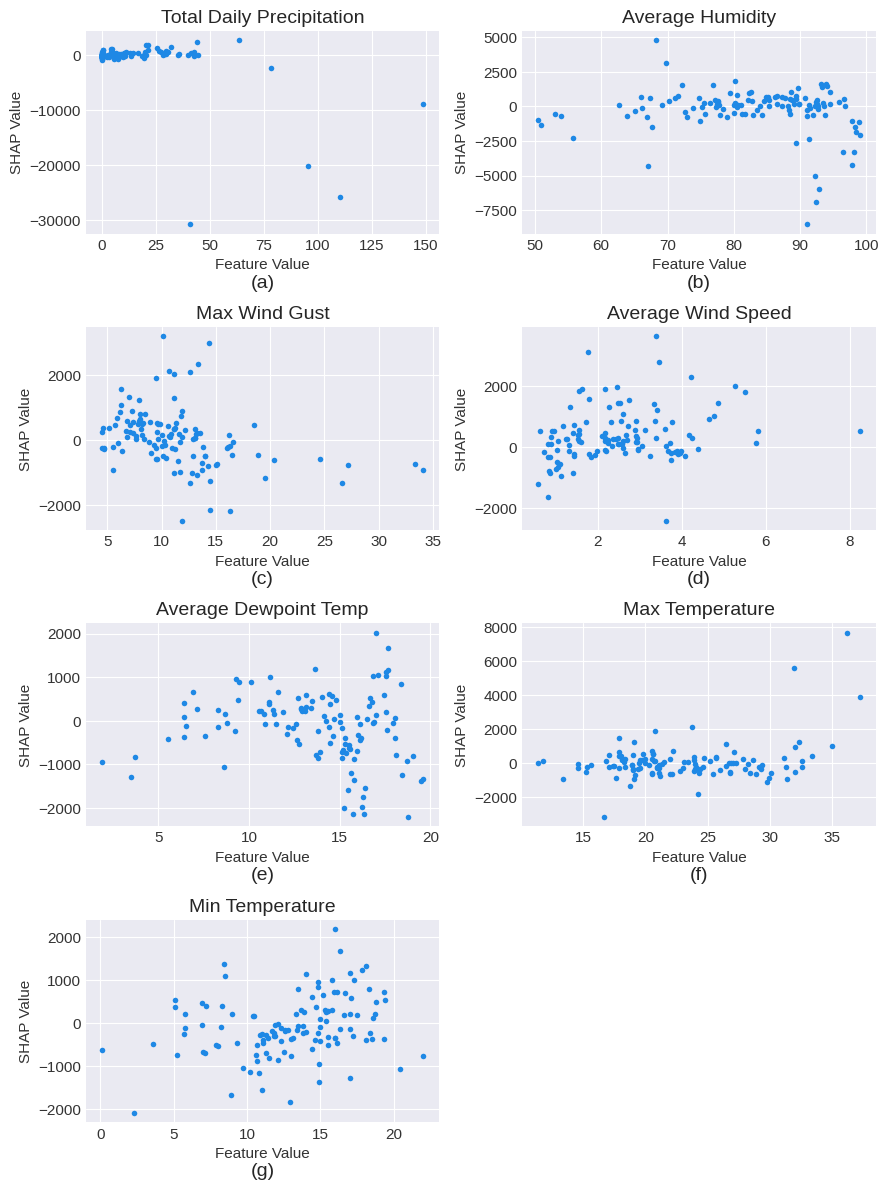

In [ ]:
import matplotlib.pyplot as plt
import shap
import string
import pandas as pd
import numpy as np

# Reset rcParams to default values for font sizes
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans']
plt.rcParams['axes.labelsize'] = 10 # Default Matplotlib size is often 10-12
plt.rcParams['xtick.labelsize'] = 8 # Default Matplotlib size is often 8-10
plt.rcParams['ytick.labelsize'] = 8 # Default Matplotlib size is often 8-10

# Apply seaborn-v0_8-darkgrid style
plt.style.use('seaborn-v0_8-darkgrid')

print("Generating combined SHAP dependence plots for meteorological features...")

# Define meteorological features explicitly within this cell
meteorological_features = [
    'Total_daily_precipitation',
    'Average_dewpoint_temp',
    'Max_temperature',
    'Min_temperature',
    'Average_humidity',
    'Max_wind_gust',
    'Average_wind_speed'
]

# Determine meteorological features for plotting, ordered by their importance.
# shap_values_meteorological_for_plot and X_meteorological_for_plot are from the previous cell execution.
mean_abs_shap_values = np.abs(shap_values_meteorological_for_plot).mean(axis=0)
feature_importance_series = pd.Series(mean_abs_shap_values, index=X_meteorological_for_plot.columns)

# Filter feature_importance_series to only include meteorological features
meteorological_importance_series = feature_importance_series[feature_importance_series.index.isin(meteorological_features)]

# Sort these meteorological features by importance
ordered_meteorological_features_for_dep_plot = meteorological_importance_series.sort_values(ascending=False).index.tolist()

print("All meteorological features (ordered by importance):")
for i, feature_name in enumerate(ordered_meteorological_features_for_dep_plot):
    print(f"{i+1}. {feature_name}")

# Create a figure with a grid suitable for the number of meteorological features
num_features_to_plot = len(ordered_meteorological_features_for_dep_plot)
num_cols = 2
num_rows = (num_features_to_plot + num_cols - 1) // num_cols # Ceiling division

fig, axes = plt.subplots(num_rows, num_cols, figsize=(9, 3 * num_rows)) # Adjust figsize for better spacing
axes = axes.flatten() # Flatten the array of axes for easy iteration

# Iterate through the features and subplots
alphabet = list(string.ascii_lowercase) # 'a', 'b', 'c', ...

for i, feature in enumerate(ordered_meteorological_features_for_dep_plot):
    ax = axes[i]
    print(f"  - Plotting Dependence Plot ({alphabet[i]}) for: {feature}")
    # Generate the SHAP dependence plot for each feature.
    shap.dependence_plot(
        feature,
        shap_explanation_only_meteorological.values,
        X_only_meteorological,
        interaction_index=None,
        show=False,
        ax=ax
    )
    # Define titles and labels in English with standard font sizes
    ax.set_title(f'{feature.replace("_", " ").title()}', fontsize=14)
    ax.set_xlabel('Feature Value', fontsize=11)
    ax.set_ylabel('SHAP Value', fontsize=11)

    # Add a letter below each subplot.
    ax.text(0.5, -0.20, f'({alphabet[i]})', transform=ax.transAxes,
            fontsize=14, va='top', ha='center') # Position of the letter below the x-axis

# Remove any unused subplots
for j in range(num_features_to_plot, len(axes)):
    fig.delaxes(axes[j])

# Use plt.tight_layout() to adjust the subplot parameters for a compact layout.
plt.tight_layout()

# Save the combined image as a TIFF file.
filename = 'combined_shap_dependence_plots_meteorological_features.tiff' # New descriptive filename
plt.savefig(filename, dpi=300, format='tiff')
print(f"\nCombined SHAP dependence plots saved to {filename}")

# Display the plot
plt.show()
